In [104]:
import os,sys,copy
import torchvision
import argparse
import torch
import tqdm

os.environ["CUDA_VISIBLE_DEVICES"]='3'


# conda install -n ocr   conda-forge::libgl   for import cv2 succus

In [342]:
def molIDX(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(i)  #映射
        # print(i)
    return mol

def molIDX_del(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(0)  #映射
        print(i)
    return mol

In [106]:
sys.path.append("/home/jovyan/rt-detr/rt-detr")
os.chdir('/home/jovyan/rt-detr/rt-detr')
from src.solver.utils import output_to_smiles

In [107]:

import src.misc.dist as dist 
from src.core import YAMLConfig 
from src.solver import TASKS 
from src.data import get_coco_api_from_dataset

from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral
from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text
import draw_box_utils
from PIL import ImageColor
import PIL.ImageDraw as ImageDraw
import numpy as np
import src
from rdkit.Chem import Draw, AllChem

import rdkit
from rdkit import Chem


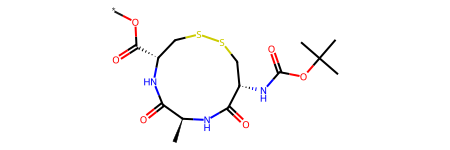

In [108]:
#C[C@@H]1NC([C@H](CSSC[C@H](NC1=O)C(O[TAGa])=O)NC(OC(C)(C)C)=O)=O #TODO reuse the data, smi token checking first
Chem.MolFromSmiles('C[C@@H]1NC([C@H](CSSC[C@H](NC1=O)C(O[*])=O)NC(OC(C)(C)C)=O)=O')

In [109]:
atom = Chem.Atom("*")
Chem.SetAtomAlias(atom, "CF3")


In [110]:
import pandas as pd

In [111]:
smiles_data = pd.DataFrame({'file_name': [],
                            'SMILESori':[],
                            'SMILESpre':[]
                            }
                            )

In [112]:
new_row = {'file_name':1, "SMILESori":5,
        'SMILESpre':344,#with *  without expand
        'SMILESexp':36, 
        }
smiles_data._append(new_row, ignore_index=True)


,file_name,SMILESori,SMILESpre,SMILESexp
0,1.0,5.0,344.0,36.0


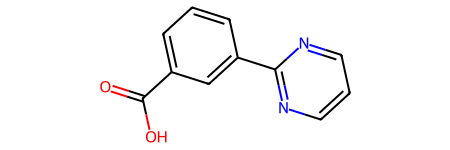

In [113]:
mm=Chem.MolFromSmiles("O=C(O)C1=CC=CC(C2=NC=CC=N2)=C1")
Chem.SanitizeMol(mm)
mm

In [114]:
Chem.MolFromSmiles('O=Cc1cccc(-c2ccccN2)c1')


In [115]:
from SmilesPE.pretokenizer import atomwise_tokenizer
def canonicalize_smiles(smiles, ignore_chiral=False, ignore_cistrans=False, replace_rgroup=True):
    if type(smiles) is not str or smiles == '':
        return '', False
    if ignore_cistrans:
        smiles = smiles.replace('/', '').replace('\\', '')
    if replace_rgroup:
        tokens = atomwise_tokenizer(smiles)
        for j, token in enumerate(tokens):
            if token[0] == '[' and token[-1] == ']':
                symbol = token[1:-1]
                if symbol[0] == 'R' and symbol[1:].isdigit():
                    tokens[j] = f'[{symbol[1:]}*]'
                elif Chem.AtomFromSmiles(token) is None:
                    tokens[j] = '*'
        smiles = ''.join(tokens)
    try:
        canon_smiles = Chem.CanonSmiles(smiles, useChiral=(not ignore_chiral))
        success = True
    except:
        canon_smiles = smiles
        success = False
    return canon_smiles, success

In [116]:
smiles='[EDG]N(C)(C)C(F)(F)'
tokens = atomwise_tokenizer(smiles)
tokens
# mol = Chem.MolFromSmiles(odd_s, sanitize=False)
# Chem.MolToSmiles(mol)


['[EDG]', 'N', '(', 'C', ')', '(', 'C', ')', 'C', '(', 'F', ')', '(', 'F', ')']

In [117]:
from PIL import Image
import torch
from torchvision import transforms
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as F

def image_to_tensor(image_path,debug=True):
    image = Image.open(image_path)
    w, h = image.size
    
    # 处理灰度或其他模式
    if image.mode == "L":
        if debug: print("检测到灰度图像 (1 通道)，转换为 RGB...")
        image = image.convert("RGB")
    elif image.mode != "RGB":
        if debug: print(f"检测到 {image.mode} 模式，转换为 RGB...")
        image = image.convert("RGB")
    # Define a transform to convert the image to a tensor and normalize it
    transform = T.Compose([
            T.Resize((640, 640)),  # 调整大小
            # T.ToImageTensor(),  # 转换为 PyTorch Tensor
            T.ToTensor(),
            lambda x: x.to(torch.float32),  # 手动转换数据类型# T.ConvertDtype(dtype=torch.float32),  # 转换数据类型
        ])
    
    # Apply the transform to the image
    tensor = transform(image)
    
    return tensor,w,h

def show_atom_number(mol, label='molAtomMapNumber'):
    for atom in mol.GetAtoms():
        atom.SetProp(label, str(atom.GetIdx()))
    return mol
    
def remove_atom_number(mol, label='molAtomMapNumber'):
    # After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property
    return mol

# After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property

def remove_SP(input_string):
    # if "S@SP1" in input_string:
    #     input_string = input_string.replace("S@SP1", "S")
    # elif "S@SP2" in input_string:
    #     input_string = input_string.replace("S@SP2", "S")
    # elif "S@SP3" in input_string:
    #     input_string = input_string.replace("S@SP3", "S")
    input_string = re.sub(r'@SP[1-3]', '', input_string)
    return input_string

import pandas as pd
import math
from scipy.spatial import cKDTree


def assemble_atoms_with_charges(atom_list, charge_list):
    used_charge_indices=set()
    kdt = cKDTree(atom_list[['x','y']])
    for i, charge in charge_list.iterrows():
        if i in used_charge_indices:
            continue
        charge_=charge['charge']
        if charge_=='1':charge_='+'
        dist, idx_atom=kdt.query([charge_list.x[i],charge_list.y[i]], k=1)
        atom_str=atom_list.loc[idx_atom,'atom'] 
        atom_ = re.findall(r'[A-Za-z]+', atom_str)[0] + charge_
        atom_list.loc[idx_atom,'atom']=atom_

    return atom_list
    


import re
pattern =  "(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
regex = re.compile(pattern)

def atomwise_tokenizer(smi, regex=regex,exclusive_tokens = None):
    """
    Tokenize a SMILES molecule at atom-level:
        (1) 'Br' and 'Cl' are two-character tokens
        (2) Symbols with bracket are considered as tokens

    exclusive_tokens: A list of specifical symbols with bracket you want to keep. e.g., ['[C@@H]', '[nH]'].
    Other symbols with bracket will be replaced by '[UNK]'. default is `None`.
    """
    tokens = [token for token in regex.findall(smi)]
    if exclusive_tokens:
        for i, tok in enumerate(tokens):
            if tok.startswith('['):
                if tok not in exclusive_tokens:
                    tokens[i] = '[UNK]'
    return tokens



bond_labels = [13,14,15,16,17]
# idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
#             9:'I',10:'P',11:'*',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
#             16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'+2',} #NONE is single ?
idx_to_labels23={0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
                    9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
                    16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',} 
idx_to_labels30 = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
                    9:'I',10:'P',11:'H',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
                    16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'2',
                    23:'CF3',#NOTE rdkit get element not supporting group
                    24:'CN',
                    25:'Me',
                    26:'CO2Et',
                    27:'R',
                    28:'Ph',
                    29:'*',
                    }



In [118]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True,use_gpu =False,
    rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer',
    lang="en")  # need to run only once to download and load model into memory

#* recong used

[2025/02/26 01:22:43] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/jovyan/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_le

In [119]:
home="/home/jovyan/rt-detr"
pt_outhome='/home/jovyan/volume/samba_share/from_docker/ocr_data/rtdetr_output'
pp="tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/best_checkpoint.pth"
cc="tools/output/rtdetr_r50vd_6x_coco_real_resample_adapter_both/checkpoint0068.pth"
tt="./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpter2/best_checkpoint.pth"
diffS='./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpterWithoutJPO_diffSize/checkpoint0071.pth'
# tr1='blured_merged_diff300start11'
# tr1='blured_merged_diff300start12'
# tr1='blured_merged_diff300start12_hand'
tr1='blured_merged_diff300start12_hand_addedObstac'
tr1='merged9'
#NOTE need change the class number@coco_detection.yml when change weight as trained in different class number 
bmd= '/home/jovyan/volume/samba_share/from_docker/ocr_data/rtdetr_output/merged9/best_checkpoint.pth'#30

parser = argparse.ArgumentParser()
parser.add_argument('--config', '-c', type=str, default=f'{home}/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/checkpoint0032.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample/checkpoint0052.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{pp}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{cc}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{diffS}')
parser.add_argument('--resume', '-r', type=str, default=f'{bmd}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{tt}')

# parser.add_argument('--resume', '-r', type=str, default=f'{pt_outhome}/{tr1}/best_checkpoint.pth')


parser.add_argument('--tuning', '-t', type=str,)# default='/home/jovyan/model_checkpoint/rtdetr_r50vd_2x_coco_objects365_from_paddle.pth')
parser.add_argument('--test-only',default=True,)
parser.add_argument('--amp', default=False,)

args, unknown = parser.parse_known_args()#in jupyter

In [120]:
cfg = YAMLConfig(
        args.config,
        resume=args.resume, 
        use_amp=args.amp,
        tuning=args.tuning
    )
# # args.gpu_device=0
cfg.device=torch.device('cuda', int(os.environ["CUDA_VISIBLE_DEVICES"])) if torch.cuda.is_available() else torch.device('cpu') 

In [121]:
[
cfg.postprocessor.num_classes,
cfg.postprocessor.use_focal_loss,
cfg.postprocessor.remap_mscoco_category,
cfg.postprocessor.iou_types,
]#rtdertpostprocessor

[30, True, False, ('bbox',)]

In [122]:
sm="*C1=CC=CC=C1"
m=Chem.MolFromSmiles(sm)
keku_smi_ori=Chem.MolToSmiles(m,kekuleSmiles=True)
keku_smi_ori

'*C1=CC=CC=C1'

In [123]:
type(cfg.val_dataloader)

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


src.data.dataloader.DataLoader

In [124]:
cfg.val_dataloader

DataLoader(
    dataset: Dataset CocoDetection
    Number of datapoints: 427
    Root location: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/images/test
     img_folder: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/images/test
     ann_file: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/annotations/test.json
     return_masks: None
     transforms:
       Compose(
          Resize(size=[640, 640], interpolation=InterpolationMode.BILINEAR, antialias=warn)
          ToImageTensor()
          ConvertDtype()
    )
    batch_size: 10
    num_workers: 4
    drop_last: False
    collate_fn: <function default_collate_fn at 0x7fef344e75e0>
)

In [125]:
# [
# cfg.data_loader,
# cfg.postprocessor.use_focal_loss,
# cfg.postprocessor.remap_mscoco_category,
# cfg.postprocessor.iou_types,
# ]#rtdertpostprocessor

In [126]:
_model=cfg.model
#postprocess need the image original size
if torch.cuda.is_available():
    saved_statDict=torch.load(cfg.resume)
else:
    saved_statDict=torch.load(cfg.resume,map_location=torch.device('cpu'))
loaded_state_dict=saved_statDict['model']
#comaparing with pretrained_model
current_model_dict=_model.state_dict()

postprocessor = cfg.postprocessor##RTDETRPostProcessor@@src/zoo/rtertr

Load PResNet50 state_dict


In [127]:
from src.zoo.rtdetr.rtdetr_postprocessor import RTDETRPostProcessor
postprocessor2=RTDETRPostProcessor(num_classes=23, use_focal_loss=True, num_top_queries=300, remap_mscoco_category=False)
postprocessor2=RTDETRPostProcessor(num_classes=30, use_focal_loss=True, num_top_queries=300, remap_mscoco_category=False)


In [128]:
[
postprocessor2.num_classes,
postprocessor2.use_focal_loss,
postprocessor2.remap_mscoco_category,
postprocessor2.iou_types,
],[
cfg.postprocessor.num_classes,
cfg.postprocessor.use_focal_loss,
cfg.postprocessor.remap_mscoco_category,
cfg.postprocessor.iou_types,
]#rtdertpostprocessor

([30, True, False, ('bbox',)], [30, True, False, ('bbox',)])

In [129]:
if postprocessor2.num_classes==30:
    idx_to_labels=idx_to_labels30
    print('idx_to_labels number', 30,idx_to_labels30)
elif postprocessor2.num_classes==23:
    print('idx_to_labels number', 23,idx_to_labels23)
    idx_to_labels=idx_to_labels23
else:
    print('idx_to_labels number', postprocessor2.num_classes)

lab2idx={ v:k  for k,v in idx_to_labels.items() }

idx_to_labels number 30 {0: 'other', 1: 'C', 2: 'O', 3: 'N', 4: 'Cl', 5: 'Br', 6: 'S', 7: 'F', 8: 'B', 9: 'I', 10: 'P', 11: 'H', 12: 'Si', 13: 'NONE', 14: 'BEGINWEDGE', 15: 'BEGINDASH', 16: '=', 17: '#', 18: '-4', 19: '-2', 20: '-1', 21: '1', 22: '2', 23: 'CF3', 24: 'CN', 25: 'Me', 26: 'CO2Et', 27: 'R', 28: 'Ph', 29: '*'}


In [130]:
#loaidng trained weights

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

#NOTE make sure current_model_dict contating all the loaded_state_dict
key_ori=loaded_state_dict.keys()
key_cur=current_model_dict.keys()
diff_cur=[k for k in key_cur  if k not in key_ori]
diff_ori=[k for k in key_ori if k not in key_cur]#loaded is the original as pretrained
#hehre we only considering new model >= pretrained, not the other case here
same_=[k for k in key_cur if k in key_ori]
# assert len(diff_ori)==0, 
print(f'make sure loaded pretrained model keys: {len(key_ori)} are all included in current build model keys: {len(key_cur)}\n In futhre we considering only part intersection!!')
new_state_dict=dict()
i=0;j=0
for k in same_:
    if loaded_state_dict[k].size()==current_model_dict[k].size():
        new_state_dict[k]=loaded_state_dict[k]
        # print(f'current{k},{current_model_dict[k].size()},ori{loaded_state_dict[k].size()}')
        i+=1
    else:
        new_state_dict[k]=current_model_dict[k] #confg such image_size diff lead
        j+=1
_model.load_state_dict(new_state_dict, strict=False)
print(f'{bcolors.WARNING}have partly load the match paramters>>number of:{len(new_state_dict.keys())}@finalLoad, all:{len(current_model_dict.keys())}@buildModel, {len(loaded_state_dict.keys())}@pretrained. {bcolors.ENDC}')
print(f' {bcolors.WARNING} loaded keys {i}, skip mismatch size keys {j} (same nnName but diff dimensions)')


make sure loaded pretrained model keys: 808 are all included in current build model keys: 808
 In futhre we considering only part intersection!!
have partly load the match paramters>>number of:808@finalLoad, all:808@buildModel, 808@pretrained. 
  loaded keys 808, skip mismatch size keys 0 (same nnName but diff dimensions)


In [131]:
print("when training use this as valdation dataset::",
    cfg.yaml_cfg['val_dataloader']['dataset']['img_folder'],"\n",
cfg.yaml_cfg['val_dataloader']['dataset']['ann_file'])

# print(type(cfg.val_dataloader))#note this val_dataloader is the training config used, not used for testing 
# print(cfg.val_dataloader.dataset)

when training use this as valdation dataset:: /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/images/test 
 /home/jovyan/rt-detr/data/real_processed/JPO_with_charge/annotations/test.json


In [132]:
opts = Draw.MolDrawOptions()
opts.addAtomIndices = False
opts.addStereoAnnotation = False

In [133]:
"""
NOTE 手画和normal keep same labels diction
#generate the hand drawing style image with annotation
python /home/jovyan/volume/samba_share/from_docker/cdk_tsv_process01.py
TODO try mergeing normal and hand drawing
"""

'\nNOTE 手画和normal keep same labels diction\n#generate the hand drawing style image with annotation\npython /home/jovyan/volume/samba_share/from_docker/cdk_tsv_process01.py\nTODO try mergeing normal and hand drawing\n'

In [134]:
"""
cp csvfiles in *with_charge
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/preprocess_data_charge.py 
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #train
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #val
--->val_dataloader: from  configs/dataset/coco_detection.yml as the above prepared:
img_folder: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/val
ann_file: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/annotations/val.json
nohup python ~/rt-detr/rt-detr/tools/train.py  > train_chembl.log 2>&1 &
nohup python ~/rt-detr/rt-detr/tools/train.py  >> train_mergedChargeWithOutJPO.log 2>&1 &
#NOTE need check args for training and testing output csv, testing need specify the above ann_file,img_folder
python ~/rt-detr/rt-detr/tools/test.py 
cd /home/jovyan/rt-detr/rt-detr
python /home/jovyan/rt-detr/LG_SMILES_1st-main/validation.py
#OCR correct
python /home/jovyan/rt-detr/rt-detr/bo_padlleOCR.py

"""

#CELF match:854,unmatch:3   99.64%
#CELF+OCRstring match:856,unmatch:1  overlapping atoms  99.88%

#staker match:44467, unmatch:1010, erros:16  (不考虑/\异构)
#staker+OCR: match: 170+44467,  unmatch:840

#acs   match:247,unmatch:20,  
#acs+OCR match:247+5,unmatch:15,  with * box expand=5 corrected ::5,uncorrected::15  total::20

#USPTO match:5351,unmatch:66
#USPTO+OCR match:5351+1,unmatch:66-1  corrected ::1,uncorrected::65  total::66 with *box_expand::0

#UOB match:4135,unmatch:37
#UOB+OCR match:4135+4,unmatch:37-4  corrected ::4,uncorrected::33  total::37 with *box_expand::0

#JPO match:417,unmatch:10,erros:0
#JPO+OCR match:417+1,unmatch:10-1,erros:0  corrected ::4,uncorrected::33  total::37 with *box_expand::0




#model 预测miss  rdkti  画图atom overalaping,   构建有坐标2D 图 可以easy checking

# /home/jovyan/rt-detr/data/OCSR_Review/assets/reference

'\ncp csvfiles in *with_charge\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/preprocess_data_charge.py \npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #train\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #val\n--->val_dataloader: from  configs/dataset/coco_detection.yml as the above prepared:\nimg_folder: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/val\nann_file: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/annotations/val.json\nnohup python ~/rt-detr/rt-detr/tools/train.py  > train_chembl.log 2>&1 &\nnohup python ~/rt-detr/rt-detr/tools/train.py  >> train_mergedChargeWithOutJPO.log 2>&1 &\n#NOTE need check args for training and testing output csv, testing need specify the above ann_file,img_folder\npython ~/rt-detr/rt-detr/tools/test.py \ncd /home/jovyan/rt-detr/rt-detr\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/validation.py\n#OCR correct\npython /home/jovyan/rt-detr/rt-detr/bo_

In [135]:
# "/sxs/xsdfsdf.png"
os.path.basename("/sxs/xsdfsdf.png")

'xsdfsdf.png'

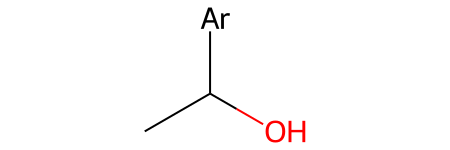

In [136]:
Chem.MolFromSmiles("[Ar]C(O)C")

In [137]:
staker_cdf=pd.read_csv(f'staker_with_charge.csv')
staker_cdf_imgs=staker_cdf['img'].to_list()
image_path=staker_cdf_imgs[1]

In [477]:
from typing import List
######################################add metric postprocess
import rdkit 
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from typing import List
from rdkit.Chem import rdchem, RWMol, CombineMols
from rdkit import Chem
from rdkit.Chem import rdFMCS
import copy
from paddleocr import PaddleOCR
import re
from rdkit import DataStructs

def MCS_mol(mcs):
    #mcs_smart = mcs.smartsString
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    AllChem.Compute2DCoords(mcs_mol)
    return mcs_mol

def g_atompair_matches(pair,mcs):
    mcs_mol = MCS_mol(mcs)
    matches0 = pair[0].GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    matches1 = pair[1].GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    if len(matches0) != len(matches1):
        matches0=list(matches0)
        matches1=list(matches1)
        # print( "noted: matcher not equal !!")
        if len(matches0)>len(matches1):
            for i in range(0,len(matches0)):
                if i < len(matches1):
                    pass
                else:
                    ii=i % len(matches1)
                    matches1.append(matches1[ii])
        else:
            for i in range(0,len(matches1)):
                if i < len(matches0):
                    pass
                else:
                    ii=i % len(matches0)
                    matches0.append(matches0[ii])
    assert len(matches0) == len(matches1), "matcher not equal break!!"
    atommaping_pairs=[list(zip(matches0[i],matches1[i])) for i in range(0,len(matches0))]
    return atommaping_pairs


class CustomError(Exception):
    """A custom exception for specific errors."""
    pass

bond_dirs = {'NONE':    Chem.rdchem.BondDir.NONE,
                'ENDUPRIGHT':   Chem.rdchem.BondDir.ENDUPRIGHT,
                'BEGINWEDGE':   Chem.rdchem.BondDir.BEGINWEDGE,
                'BEGINDASH':    Chem.rdchem.BondDir.BEGINDASH,
            'ENDDOWNRIGHT': Chem.rdchem.BondDir.ENDDOWNRIGHT,}

VALENCES = {
    "H": [1], "Li": [1], "Be": [2], "B": [3], "C": [4], "N": [3, 5], "O": [2], "F": [1],
    "Na": [1], "Mg": [2], "Al": [3], "Si": [4], "P": [5, 3], "S": [6, 2, 4], "Cl": [1], "K": [1], "Ca": [2],
    "Br": [1], "I": [1]
}

ELEMENTS = [
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
    "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
    "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
    "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
    "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
    "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds",
    "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og"
]

COLORS = {
    u'c': '0.0,0.75,0.75', u'b': '0.0,0.0,1.0', u'g': '0.0,0.5,0.0', u'y': '0.75,0.75,0',
    u'k': '0.0,0.0,0.0', u'r': '1.0,0.0,0.0', u'm': '0.75,0,0.75'
}
RGROUP_SYMBOLS = ['R', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11', 'R12',
                  'Ra', 'Rb', 'Rc', 'Rd', 'X', 'Y', 'Z', 'Q', 'A', 'E', 'Ar']

class Substitution(object):
    '''Define common substitutions for chemical shorthand'''
    def __init__(self, abbrvs, smarts, smiles, probability):
        assert type(abbrvs) is list
        self.abbrvs = abbrvs
        self.smarts = smarts
        self.smiles = smiles
        self.probability = probability

SUBSTITUTIONS: List[Substitution] = [#abbrvs, smarts, smiles
    Substitution(['NO2', 'O2N'], '[N+](=O)[O-]', "[N+](=O)[O-]", 0.5),
    Substitution(['CHO', 'OHC'], '[CH1](=O)', "[CH1](=O)", 0.5),
    Substitution(['CO2Et', 'COOEt'], 'C(=O)[OH0;D2][CH2;D2][CH3]', "[C](=O)OCC", 0.5),

    Substitution(['OAc'], '[OH0;X2]C(=O)[CH3]', "[O]C(=O)C", 0.7),
    Substitution(['NHAc'], '[NH1;D2]C(=O)[CH3]', "[NH]C(=O)C", 0.7),
    Substitution(['Ac'], 'C(=O)[CH3]', "[C](=O)C", 0.1),

    Substitution(['OBz'], '[OH0;D2]C(=O)[cH0]1[cH][cH][cH][cH][cH]1', "[O]C(=O)c1ccccc1", 0.7),  # Benzoyl
    Substitution(['Bz'], 'C(=O)[cH0]1[cH][cH][cH][cH][cH]1', "[C](=O)c1ccccc1", 0.2),  # Benzoyl

    Substitution(['OBn'], '[OH0;D2][CH2;D2][cH0]1[cH][cH][cH][cH][cH]1', "[O]Cc1ccccc1", 0.7),  # Benzyl
    Substitution(['Bn'], '[CH2;D2][cH0]1[cH][cH][cH][cH][cH]1', "[CH2]c1ccccc1", 0.2),  # Benzyl

    Substitution(['NHBoc'], '[NH1;D2]C(=O)OC([CH3])([CH3])[CH3]', "[NH1]C(=O)OC(C)(C)C", 0.6),
    Substitution(['NBoc'], '[NH0;D3]C(=O)OC([CH3])([CH3])[CH3]', "[NH1]C(=O)OC(C)(C)C", 0.6),
    Substitution(['Boc'], 'C(=O)OC([CH3])([CH3])[CH3]', "[C](=O)OC(C)(C)C", 0.2),

    Substitution(['Cbm'], 'C(=O)[NH2;D1]', "[C](=O)N", 0.2),
    Substitution(['Cbz'], 'C(=O)OC[cH]1[cH][cH][cH1][cH][cH]1', "[C](=O)OCc1ccccc1", 0.4),
    Substitution(['Cy'], '[CH1;X3]1[CH2][CH2][CH2][CH2][CH2]1', "[CH1]1CCCCC1", 0.3),
    Substitution(['Fmoc'], 'C(=O)O[CH2][CH1]1c([cH1][cH1][cH1][cH1]2)c2c3c1[cH1][cH1][cH1][cH1]3',
                 "[C](=O)OCC1c(cccc2)c2c3c1cccc3", 0.6),
    Substitution(['Mes'], '[cH0]1c([CH3])cc([CH3])cc([CH3])1', "[c]1c(C)cc(C)cc(C)1", 0.5),
    Substitution(['OMs'], '[OH0;D2]S(=O)(=O)[CH3]', "[O]S(=O)(=O)C", 0.7),
    Substitution(['Ms'], 'S(=O)(=O)[CH3]', "[S](=O)(=O)C", 0.2),
    Substitution(['Ph'], '[cH0]1[cH][cH][cH1][cH][cH]1', "[c]1ccccc1", 0.5),
    Substitution(['PMB'], '[CH2;D2][cH0]1[cH1][cH1][cH0](O[CH3])[cH1][cH1]1', "[CH2]c1ccc(OC)cc1", 0.2),
    Substitution(['Py'], '[cH0]1[n;+0][cH1][cH1][cH1][cH1]1', "[c]1ncccc1", 0.1),
    Substitution(['SEM'], '[CH2;D2][CH2][Si]([CH3])([CH3])[CH3]', "[CH2]CSi(C)(C)C", 0.2),
    Substitution(['Suc'], 'C(=O)[CH2][CH2]C(=O)[OH]', "[C](=O)CCC(=O)O", 0.2),
    Substitution(['TBS'], '[Si]([CH3])([CH3])C([CH3])([CH3])[CH3]', "[Si](C)(C)C(C)(C)C", 0.5),
    Substitution(['TBZ'], 'C(=S)[cH]1[cH][cH][cH1][cH][cH]1', "[C](=S)c1ccccc1", 0.2),
    Substitution(['OTf'], '[OH0;D2]S(=O)(=O)C(F)(F)F', "[O]S(=O)(=O)C(F)(F)F", 0.7),
    Substitution(['Tf'], 'S(=O)(=O)C(F)(F)F', "[S](=O)(=O)C(F)(F)F", 0.2),
    Substitution(['TFA'], 'C(=O)C(F)(F)F', "[C](=O)C(F)(F)F", 0.3),
    Substitution(['TMS'], '[Si]([CH3])([CH3])[CH3]', "[Si](C)(C)C", 0.5),
    Substitution(['Ts'], 'S(=O)(=O)c1[cH1][cH1][cH0]([CH3])[cH1][cH1]1', "[S](=O)(=O)c1ccc(C)cc1", 0.6),  # Tos

    # Alkyl chains
    Substitution(['OMe', 'MeO'], '[OH0;D2][CH3;D1]', "[O]C", 0.3),
    Substitution(['SMe', 'MeS'], '[SH0;D2][CH3;D1]', "[S]C", 0.3),
    Substitution(['NMe', 'MeN'], '[N;X3][CH3;D1]', "[NH]C", 0.3),
    Substitution(['Me'], '[CH3;D1]', "[CH3]", 0.1),
    Substitution(['OEt', 'EtO'], '[OH0;D2][CH2;D2][CH3]', "[O]CC", 0.5),
    Substitution(['Et', 'C2H5'], '[CH2;D2][CH3]', "[CH2]C", 0.3),
    Substitution(['Pr', 'nPr', 'n-Pr'], '[CH2;D2][CH2;D2][CH3]', "[CH2]CC", 0.3),
    Substitution(['Bu', 'nBu', 'n-Bu'], '[CH2;D2][CH2;D2][CH2;D2][CH3]', "[CH2]CCC", 0.3),

    # Branched
    Substitution(['iPr', 'i-Pr'], '[CH1;D3]([CH3])[CH3]', "[CH1](C)C", 0.2),
    Substitution(['iBu', 'i-Bu'], '[CH2;D2][CH1;D3]([CH3])[CH3]', "[CH2]C(C)C", 0.2),
    Substitution(['OiBu'], '[OH0;D2][CH2;D2][CH1;D3]([CH3])[CH3]', "[O]CC(C)C", 0.2),
    Substitution(['OtBu'], '[OH0;D2][CH0]([CH3])([CH3])[CH3]', "[O]C(C)(C)C", 0.6),
    Substitution(['tBu', 't-Bu'], '[CH0]([CH3])([CH3])[CH3]', "[C](C)(C)C", 0.3),

    # Other shorthands (MIGHT NOT WANT ALL OF THESE)
    Substitution(['CF3', 'F3C'], '[CH0;D4](F)(F)F', "[C](F)(F)F", 0.5),
    Substitution(['NCF3', 'F3CN'], '[N;X3][CH0;D4](F)(F)F', "[NH]C(F)(F)F", 0.5),
    Substitution(['OCF3', 'F3CO'], '[OH0;X2][CH0;D4](F)(F)F', "[O]C(F)(F)F", 0.5),
    Substitution(['CCl3'], '[CH0;D4](Cl)(Cl)Cl', "[C](Cl)(Cl)Cl", 0.5),
    Substitution(['CO2H', 'HO2C', 'COOH'], 'C(=O)[OH]', "[C](=O)O", 0.5),  # COOH
    Substitution(['CN', 'NC'], 'C#[ND1]', "[C]#N", 0.5),
    Substitution(['OCH3', 'H3CO'], '[OH0;D2][CH3]', "[O]C", 0.4),
    Substitution(['SO3H'], 'S(=O)(=O)[OH]', "[S](=O)(=O)O", 0.4),
]
ABBREVIATIONS = {abbrv: sub for sub in SUBSTITUTIONS for abbrv in sub.abbrvs}
def _expand_abbreviation(abbrev):
    """
    Expand abbreviation into its SMILES; also converts [Rn] to [n*]
    Used in `_condensed_formula_list_to_smiles` when encountering abbrev. in condensed formula
    """
    if abbrev in ABBREVIATIONS:
        return ABBREVIATIONS[abbrev].smiles
    elif abbrev in RGROUP_SYMBOLS or (abbrev[0] == 'R' and abbrev[1:].isdigit()):
        if abbrev[1:].isdigit():
            return f'[{abbrev[1:]}*]'
    elif abbrev in ELEMENTS:#ocr tool need this
        return f'[{abbrev}]'
    match = re.match(r'^(\d+)?(.*)', abbrev)
    if match:
        numeric_part, remaining_part = match.groups()
        if remaining_part in ELEMENTS:
            return f'[{abbrev}]'
        else:
            if numeric_part:
                abbrev=f'[{numeric_part}*]'
    return '[*]'


def expandABB(mol,ABBREVIATIONS, placeholder_atoms):
    mols = [mol]
    # **第三步: 替换 * 并合并官能团**
    # 逆序遍历 placeholder_atoms，确保删除后不会影响后续索引
    for idx in sorted(placeholder_atoms.keys(), reverse=True):
        group = placeholder_atoms[idx]  # 获取官能团名称
        # print(idx, group)
        group=_expand_abbreviation(group)
        submol = Chem.MolFromSmiles(group)  # 获取官能团的子分子
        submol_rw = RWMol(submol)  # 让 submol 变成可编辑的 RWMol
        anchor_atom_idx = 0  # 选择 `submol` 的第一个原子作为连接点 as defined in ABBREVIATIONS
        # **1. 复制主分子**
        new_mol = RWMol(mol)
        # **2. 计算 `*` 在 `new_mol` 中的索引**
        placeholder_idx = idx
        # **3. 记录 `*` 原子的邻居**
        neighbors = [nb.GetIdx() for nb in new_mol.GetAtomWithIdx(placeholder_idx).GetNeighbors()]
        # **4. 断开 `*` 的所有键**
        bonds_to_remove = []  # 记录要断开的键
        for bond in new_mol.GetBonds():
            if bond.GetBeginAtomIdx() == placeholder_idx or bond.GetEndAtomIdx() == placeholder_idx:
                bonds_to_remove.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
        for bond in bonds_to_remove:
            new_mol.RemoveBond(bond[0], bond[1])
        # **5. 删除 `*` 原子**
        new_mol.RemoveAtom(placeholder_idx)
        # **6. 重新计算 `neighbors`（删除后索引变化）**
        new_neighbors = []
        for neighbor in neighbors:
            if neighbor < placeholder_idx:
                new_neighbors.append(neighbor)
            else:
                new_neighbors.append(neighbor - 1)  # 因为删除了一个原子，所有索引 -1
        # **7. 合并 `submol`**
        new_mol = RWMol(CombineMols(new_mol, submol_rw))

        # **8. 计算 `submol` 的第一个原子在合并后的位置**
        new_anchor_idx = new_mol.GetNumAtoms() - len(submol_rw.GetAtoms()) + anchor_atom_idx

        # **9. 重新连接官能团**
        for neighbor in new_neighbors:
            # print(neighbor, new_anchor_idx, "!!")
            new_mol.AddBond(neighbor, new_anchor_idx, Chem.BondType.SINGLE)#TODO Fix me should use delted bondtype
            a1=new_mol.GetAtomWithIdx(neighbor)
            a2=new_mol.GetAtomWithIdx(new_anchor_idx)
            a1.SetNumRadicalElectrons(0)
            a2.SetNumRadicalElectrons(0)## 将自由基电子数设为 0,as has added new bond
        # **10. 更新主分子**
        mol = new_mol
        mols.append(mol)
    # 输出修改后的分子 SMILES
    modified_smiles = Chem.MolToSmiles(mols[-1])
    # print(f"修改后的分子 SMILES: {modified_smiles}")            
    return mols[-1], modified_smiles

def molExpanding(mol_rebuit,placeholder_atoms,wdbs,bond_dirs):
    cm=copy.deepcopy(mol_rebuit)
    # print(placeholder_atoms)
    expand_mol, expand_smiles= expandABB(cm,ABBREVIATIONS, placeholder_atoms)
    rdm=copy.deepcopy(expand_mol)
    AllChem.Compute2DCoords(rdm)
    target_mol, ref_mol=rdm, cm
    mcs=rdFMCS.FindMCS([target_mol, ref_mol], # larger,small order
                    atomCompare=rdFMCS.AtomCompare.CompareAny,
                    bondCompare=rdFMCS.BondCompare.CompareAny,
                    ringCompare=rdFMCS.RingCompare.IgnoreRingFusion,
                    matchChiralTag=False,
    )
    # mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    # matches0 = target_mol.GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    # matches1 = ref_mol.GetSubstructMatches(mcs_mol, useQueryQueryMatches=True,uniquify=False, maxMatches=1000, useChirality=False)
    # assert len(matches0) == len(matches1), "matcher not equal break!!"
    atommaping_pairs=g_atompair_matches([target_mol, ref_mol],mcs)

    # atommaping_pairs=[list(zip(matches0[i],matches1[i])) for i in range(0,len(matches0))]
    # if len(atommaping_pairs)>1:
    #     atomMap=atommaping_pairs[0]
    # else:
    #     atomMap=atommaping_pairs
    #always list of list
    atomMap=atommaping_pairs[0]
        
    try:
        rmsd2=rdkit.Chem.rdMolAlign.AlignMol(prbMol=target_mol, refMol=ref_mol, atomMap=atomMap,maxIters=2000000)
    except Exception as e:
        print(atomMap,"@@@@")
        print(e)
    #after get atomMap
    c2p={cur:pre for cur, pre in atomMap}
    p2c={pre:cur for cur, pre in atomMap}
    for b in wdbs:#add bond direction
        p0,p1=int(b[0]), int(b[1])#may be not in the atomMap as the mcs_sub
        if p0 in p2c.keys() and p1 in p2c.keys():
            c0,c1=p2c[p0],p2c[p1]
            # print("[pre0,pre1]vs[c0,c1]current atom id",[p0,p1],[c0,c1])
            b_=target_mol.GetBondBetweenAtoms(c0,c1)
            if b_:
                b_.SetBondDir(bond_dirs[b[3]])
    expandStero_smi=Chem.MolToSmiles(target_mol)#directly will not add the stero info into smiles, must have the assing steps
    m=target_mol.GetMol()
    # Chem.SanitizeMol(m)
    Chem.DetectBondStereochemistry(m)
    Chem.AssignChiralTypesFromBondDirs(m)
    Chem.AssignStereochemistry(m)#expandStero_smi ,  m 
    return expandStero_smi, m  
##############################################################
# Helper function to check if two boxes overlap
def boxes_overlap(box1, box2):
    x1, y1, x2, y2 = box1
    bx1, by1, bx2, by2 = box2
    return not (x2 < bx1 or x1 > bx2 or y2 < by1 or y1 > by2)

def boxes_overlap2(atombonx, bondbox):
    """
    检查两个矩形框是否重叠，并返回 bondbox 中不重叠一端到中心 10% 位置的坐标。
    
    参数:
        atombonx: tuple (x1, y1, x2, y2) 表示原子框的坐标
        bondbox: tuple (bx1, by1, bx2, by2) 表示键框的坐标
        
    返回:
        tuple (x, y) 表示 bondbox 不重叠一端到中心 80% 位置的坐标，如果完全包含返回 (None, None)
    """
    x1, y1, x2, y2 = atombonx
    bx1, by1, bx2, by2 = bondbox
    
    # 计算 bond_box 的中心坐标
    bond_center_x = (bx1 + bx2) / 2
    bond_center_y = (by1 + by2) / 2
    
    # 辅助函数：计算点到 atom_box 中心的距离
    def distance_to_center(x, y):
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        return ((x - center_x) ** 2 + (y - center_y) ** 2) ** 0.5
    
    # 辅助函数：计算从中心到端点 80% 位置的坐标
    def get_80_percent_point(far_x, far_y):
        # 从中心到端点的向量，按 80% 比例缩放
        dx = far_x - bond_center_x
        dy = far_y - bond_center_y
        new_x = bond_center_x + 0.7 * dx#let added H close to the heavy neighbor
        new_y = bond_center_y + 0.7 * dy
        return new_x, new_y
    
    # 检查是否完全不相交
    if (bx2 < x1 or bx1 > x2 or by2 < y1 or by1 > y2):
        # 完全不相交，返回较远一端到中心 80% 位置
        dist1 = distance_to_center(bx1, by1)
        dist2 = distance_to_center(bx2, by2)
        far_x, far_y = (bx2, by2) if dist2 > dist1 else (bx1, by1)
        return get_80_percent_point(far_x, far_y)
    
    # 检查是否完全包含在 atom_box 内
    if (bx1 >= x1 and bx2 <= x2 and by1 >= y1 and by2 <= y2):
        # bondbox 完全在 atom_box 内，无法确定不重叠部分，返回 None
        return None, None
    
    # 检查一端是否在 atom_box 内
    if (bx1 >= x1 and bx1 <= x2 and by1 >= y1 and by1 <= y2):
        # bx1, by1 在 atom_box 内，返回 bx2, by2 到中心 80% 位置
        return get_80_percent_point(bx2, by2)
    elif (bx2 >= x1 and bx2 <= x2 and by2 >= y1 and by2 <= y2):
        # bx2, by2 在 atom_box 内，返回 bx1, by1 到中心 80% 位置
        return get_80_percent_point(bx1, by1)
    
    # 处理部分相交但两端都不在 atom_box 内的情况
    # 返回较远一端到中心 80% 位置
    dist1 = distance_to_center(bx1, by1)
    dist2 = distance_to_center(bx2, by2)
    far_x, far_y = (bx2, by2) if dist2 > dist1 else (bx1, by1)
    return get_80_percent_point(far_x, far_y)

charge_labels = [18,19,20,21,22]
def outputbox_update(output,charge_labels,bond_labels):
    bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
    bond_bbox=output['bbox'][bonds_mask]
    atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
    atom_bbox=output['bbox'][atoms_mask]
    new_atoms=[]
    b_len=3
    
    for bi,bb in enumerate(bond_bbox):
        overlapped_atoms = []
        overlapped_abox=[]
        for ai,aa in enumerate(atom_bbox):
            overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
            if overlap_flag:
                # print(bb, aa,overlap_flag)
                overlapped_atoms.append(ai)
                overlapped_abox.append(aa)
        if len(overlapped_atoms) == 1:
            # Compute the non-overlapping part of the bond box to place hydrogen
            non_overlapping_x,non_overlapping_y=boxes_overlap2(overlapped_abox[0], bb)
            new_atom_out={'bbox':    np.array([non_overlapping_x - b_len, 
                                    non_overlapping_y - b_len,
                                    non_overlapping_x + b_len, 
                                    non_overlapping_y + b_len]).reshape(-1,4),
                'bbox_centers': np.array([non_overlapping_x,non_overlapping_y]).reshape(-1,2),
                'scores':       np.array([1.0]),
                'pred_classes': np.array([lab2idx['H']])}
            new_atoms.append(new_atom_out)

    output2_=copy.deepcopy(output)
    for boxout in new_atoms:
        for k,arr in boxout.items():
            value_or_row=output2_[k]
            if arr.ndim == 1:
                output2_[k]=np.append(value_or_row, arr)
            elif arr.ndim >= 2:
                output2_[k] = np.concatenate([value_or_row, arr], axis=0)
            else:
                print('errprs, unkown conditions !!!@')
    return output2_


def remove_unconnected_hydrogens(mol):
    """
    移除分子中不与重原子相连的氢原子（包括孤立 H 和只连到其他 H 的 H）。
    
    参数:
        mol: RDKit Mol 对象
        
    返回:
        移除氢原子后的 RWMol 对象
    """
    # 转换为可编辑的 RWMol 对象
    molexp = Chem.RWMol(mol)
    to_remove = []

    # 遍历所有原子
    for atom in molexp.GetAtoms():
        if atom.GetSymbol() == 'H':  # 只处理氢原子
            neighbors = atom.GetNeighbors()
            # 检查邻居中是否有重原子
            has_heavy_atom = False
            for neighbor in neighbors:
                if neighbor.GetSymbol() != 'H':  # 如果邻居不是 H，则是重原子
                    has_heavy_atom = True
                    break
            # 如果没有重原子邻居，标记为移除
            if not has_heavy_atom:
                to_remove.append(atom.GetIdx())

    # 按索引从大到小排序，避免移除时索引混乱
    to_remove.sort(reverse=True)
    
    # 移除标记的原子
    for ai in to_remove:
        molexp.RemoveAtom(ai)
    
    return molexp

In [139]:
#########################
correcte=[]
uncorrects=[]
debug=False
image_path="/home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/test/18091.png"
input_s="CC1=CC2C[Ac]=NCCOC=2C=C1"
image_path="/home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/test/49565.png"
input_s="*C1C=C2C([*])=NN=C([U])C2=CN=1"

image_path='/home/jovyan/rt-detr/data/real_processed/USPTO_with_charge/images/test/US07314883-20080101-C00493.png'
input_s='CC1=CC(CO)=CC([N+](=O)[O-])=C1[N+](=O)[O-]'





dname="CLEF"
home='/home/jovyan/rt-detr'
data_csvf=f'{home}/data/real_processed/{dname}_with_charge/{dname}.csv'
imgdir=f'{home}/data/real_processed/{dname}_with_charge/images/test/'
df_csv=pd.read_csv(data_csvf)


In [140]:
image_path=f"{imgdir}/{df_csv.file_name[0]}"
target_smiles=df_csv.SMILES[0]
print(image_path)

df_csv.head(2)


/home/jovyan/rt-detr/data/real_processed/CLEF_with_charge/images/test//US20070117785A1_p0034_x0977_y2564_c00072.png


,file_name,SMILES
0,US20070117785A1_p0034_x0977_y2564_c00072.png,CC(=O)N1CCC2=C(C1)C(C1=CC=C(C(F)(F)F)C=C1)=NN2...
1,US20050004369A1_p0017_x1399_y0692_c00023.png,OCC1=CC=C(C2=CC=C(N3C=CC4=C3C=CC=C4)C=C2)C=C1


In [141]:
xx='US20070155803A1_p0002_x1503_y1997_c00000.png'
image_path=f"{imgdir}/{xx}"
ix = df_csv.index[df_csv['file_name'] == f'{xx}'].tolist()[0]
target_smiles=df_csv.SMILES[ix]
print(target_smiles),df_csv.SMILES[i:5]


[1*]C([2*])(N)C(=O)N([3*])N([4*])C(=O)N([5*])[6*]


(None, Series([], Name: SMILES, dtype: object))

In [142]:
#check * for fingerprint 
from rdkit import DataStructs

sim1="NC(C1=CC2=C(C=CC=C2OC)N1)=O.C.C.C"#. 影响不大
sim2="NC(C1=CC2=C(C=CC=C2O[C])N1)=O"
# sim1='O=C1NCC[C@H]1C[C@@H](C)NC([C@H](CC(C)C)NC)=O'
# sim2='O=C1NCC[C@H]1C[C@H](C)NC([C@@H](CC(C)C)NC)=O'
mol1 = Chem.MolFromSmiles(sim1)
mol2 = Chem.MolFromSmiles(sim2)
morganfps1 = AllChem.GetMorganFingerprint(mol1, 3,useChirality=True)
morganfps2 = AllChem.GetMorganFingerprint(mol2, 3,useChirality=True)
morgan_tani = DataStructs.DiceSimilarity(morganfps1, morganfps2)
fp1 = Chem.RDKFingerprint(mol1)
fp2 = Chem.RDKFingerprint(mol2)
tanimoto = DataStructs.FingerprintSimilarity(fp1, fp2)
print(morgan_tani,  tanimoto)

0.8080808080808081 1.0


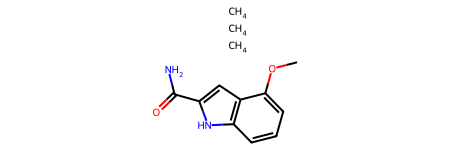

In [143]:
mol1

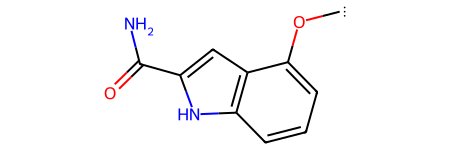

In [144]:
mol2

In [145]:
# image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/acs.joc.5b02057-Scheme-c8-6.png'
# image_path="/home/jovyan/volume/samba_share/from_docker/workspace/apex/MCSnipaste_2025-01-06_17-59-02.png"
# # image_path='/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/images/train/CDK_Depict_4_49.png'
# # image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/ol500248h-Scheme-c2-26.png'
image_path='/home/jovyan/rt-detr/data/real/acs/ja5080739-Scheme-c1-17.png'
image_path='/home/jovyan/rt-detr/data/real/acs/jo9519672-Scheme-c1-5.png'

# image_path='/home/jovyan/rt-detr/data/real/acs/acs.orglett.5b03590-Table-c2-0.png'

In [791]:
image_path="/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/images/train/CDK_Depict_42_80.png"
image_path='/home/jovyan/volume/samba_share/from_docker/workspace/fig7a.png'#paper screen
image_path='/home/jovyan/volume/samba_share/from_docker/workspace/fig7c.png'#paper screen

#real
image_path="/home/jovyan/rt-detr/data/real/acs/op990035n-Scheme-c1-7.png"
image_path="/home/jovyan/rt-detr/data/real/acs/ja206047h-Table-c1-4.png"
image_path="/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png"

# #overlap bond or cross bond
# image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/op200019k-Scheme-c6-1.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/JPO_with_charge/images/test/2008152203_25_chem.png'
#used above two on paper
# image_path='/home/jovyan/volume/samba_share/from_docker/data/acs_with_charge/images/test/67.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/JPO_with_charge/images/test/2008238710_3_chem.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/UOB_with_charge/images/test/maybridge-0313-197312003.png'
# image_path='/home/jovyan/volume/samba_share/from_docker/data/UOB_with_charge/images/test/maybridge-0239-923900285.png'



In [770]:
image_path="/home/jovyan/volume/samba_share/from_docker/data/work_space/USPTO/USRE039991-20080101-C00272.png"


图像的尺寸 [634, 323]


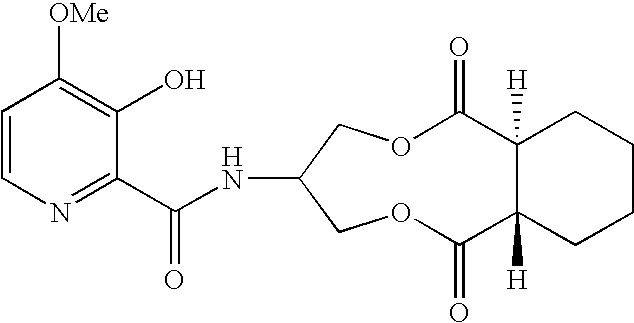

In [792]:
img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
print(f"图像的尺寸",[w_ori, h_ori ])
img_ori

atom 15 +bonds 14=29 number


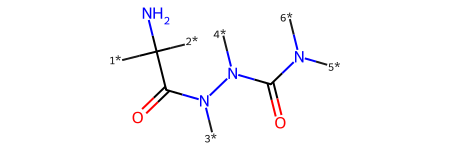

In [793]:
tmol=Chem.MolFromSmiles(target_smiles)
na=tmol.GetNumAtoms()
nb=tmol.GetNumBonds()
print(f"atom {na} +bonds {nb}={na+nb} number")
tmol

In [794]:
# import json
# annot_file="/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/annotations/train.json"
# with open(annot_file, 'r') as file: 
#     data = json.load(file)
# print(list(data.keys()))
# data['images'][-1]

In [795]:
# import json
# annot_file="/home/jovyan/volume/samba_share/from_docker/ocr_data/handDrawLike/DECIMER_HDM/annotations/val.json"
# with open(annot_file, 'r') as file: 
#     data = json.load(file)
# print(list(data.keys()))
# data['annotations']

In [796]:
image_path

'/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png'

In [797]:
# Example usage: #change thie image
tensor,w,h = image_to_tensor(image_path)
tensor=tensor.unsqueeze(0)
print(tensor.size())  # Output tensor shape (C x H x W)

_model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    print("training",_model.training)
    outputs = _model(tensor)

ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
if len(idx_to_labels)==23:
    result_ = postprocessor(outputs, ori_size)
elif len(idx_to_labels)==30:
    result_ = postprocessor2(outputs, ori_size)
else:
    print(f"error unkown ways!!")
# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
selected_indices =score_ > 0.5
# selected_indices =score_ > score_.mean()
# 统计 True 的数量
true_count = selected_indices.sum().item()
print(f"selected_indices 中 True 的数量: {true_count}")

output={
    'labels': label_[selected_indices],
    'boxes': boxe_[selected_indices],
    'scores': score_[selected_indices]
}

filtered_output_dict={image_path: output
}


x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)

#TODO split atom_charge \ bond drawing
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

检测到 1 模式，转换为 RGB...
torch.Size([1, 3, 640, 640])
training False


selected_indices 中 True 的数量: 57


In [798]:
def drawSingleBoxIma(image_path,box=[231.89378, 156.89542, 243.7499,  168.0719 ]):
    imx= draw_objs(Image.open(image_path).convert('RGB'),
                np.array(box).reshape(-1,4),
                np.array([4]),
                np.array([1.0]),
                category_index=idx_to_labels,
                box_thresh=0.5,
                line_thickness=3,
                font='arial.ttf',
                font_size=10)
    return imx

In [799]:
charge_labels = [18,19,20,21,22]
output = outputbox_update(output,charge_labels,bond_labels)#postprocess
print(len(output['bbox']),"box 个数")

59 box 个数


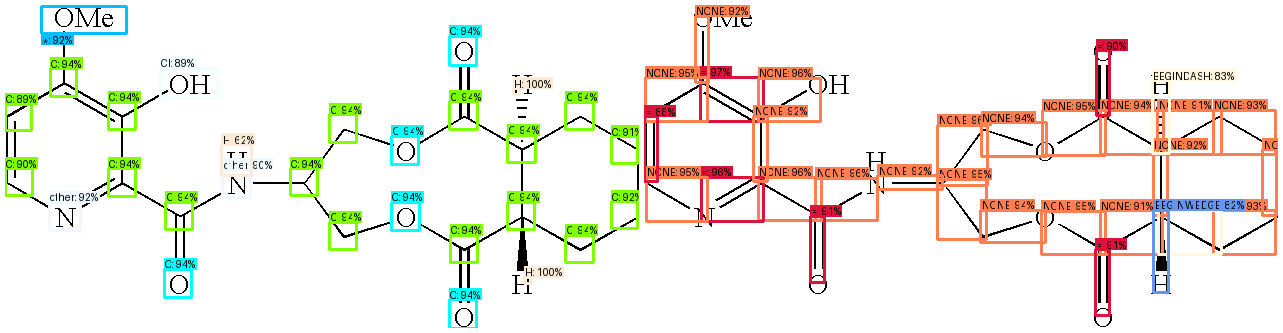

In [805]:
atom_bondBox_check=True
if atom_bondBox_check:
    bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
    bond_bbox=output['bbox'][bonds_mask]
    atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
    atom_bbox=output['bbox'][atoms_mask]

    predict_boxes = output['bbox']
    newbox = predict_boxes #* [scale_x, scale_y, scale_x, scale_y]
    predict_classes = output['pred_classes']
    predict_scores = output['scores']
    charge_labels = [18,19,20,21,22]#make influence

    bondbox_only=newbox[bonds_mask]
    b_predict_classes=predict_classes[bonds_mask]
    b_predict_scores=predict_scores[bonds_mask]
    #non bonds
    acbox_only=newbox[~bonds_mask]
    ac_predict_classes=predict_classes[~bonds_mask]
    ac_predict_scores=predict_scores[~bonds_mask]


    padding=5
    atombox_img=draw_objs(Image.open(image_path).convert('RGB'),
                        acbox_only,ac_predict_classes,ac_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    bonbox_img=draw_objs(Image.open(image_path).convert('RGB'),
                        bondbox_only,b_predict_classes,b_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)
    # Get sizes of the individual images
    atom_width, atom_height = atombox_img.size
    bon_width, bon_height = bonbox_img.size
    combined_width = atom_width + bon_width + padding * 3
    combined_height = max(atom_height, bon_height) + padding * 2
    combined_img = Image.new('RGB', (combined_width, combined_height), color=(255, 255, 255))  # White background
    # Paste the images onto the new canvas
    combined_img.paste(atombox_img, (padding, padding))  # Top-left
    combined_img.paste(bonbox_img, (atom_width + padding * 2, padding))  # Top-right
else:
    combined_img=None
combined_img

In [806]:
#box2 mol
charge_mask = np.array([True if ins  in charge_labels else False for ins in output['pred_classes']])
charges_bbox=output['bbox'][charge_mask]
charges_centers= output['bbox_centers'][charge_mask]
charges_classes= output['pred_classes'][charge_mask]


bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
bond_bbox=output['bbox'][bonds_mask]
bond_centers= output['bbox_centers'][bonds_mask]
bond_classes= output['pred_classes'][bonds_mask]


heavy_mask= np.array([True if ins not in bond_labels and ins not in charge_labels and ins != lab2idx['H'] else False for ins in output['pred_classes']])
h_mask= np.array([True if ins not in bond_labels and ins not in charge_labels and ins == lab2idx['H'] else False for ins in output['pred_classes']])

heavy_bbox = output['bbox'][heavy_mask]
heavy_classes = output['pred_classes'][heavy_mask]
heavy_centers= output['bbox_centers'][heavy_mask]

h_bbox = output['bbox'][h_mask]
h_centers= output['bbox_centers'][h_mask]
h_classes= output['pred_classes'][h_mask]
#NOTE need keep the order heavy atom first then following with Hs
# atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
# atom_bbox=output['bbox'][atoms_mask]
# atom_classes=output['pred_classes'][atoms_mask]
# 合并 bbox，保持重原子在前，氢原子在后
atom_bbox = np.concatenate([heavy_bbox, h_bbox], axis=0)
atom_classes = np.concatenate([heavy_classes, h_classes], axis=0)
atom_centers = np.concatenate([heavy_centers, h_centers], axis=0)
print(f"atom box {len(atom_bbox)} bond box {len(bond_bbox)}  charge box {len(charges_bbox)} ")
print(f"heavy box {len(heavy_bbox)}\nH box {len(h_bbox)}")

atom box 29 bond box 30  charge box 0 
heavy box 26
H box 3


In [807]:
b2a=dict()
a2b=dict()

for bi,bb in enumerate(bond_bbox):
    overlapped_atoms = []
    overlapped_abox=[]
    for ai,aa in enumerate(atom_bbox):#need update the atom_bbox order heavy first then H atoms
        overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
        if overlap_flag:
            # print(bb, aa,overlap_flag)
            overlapped_atoms.append(ai)
            overlapped_abox.append(aa)
            if bi not in b2a.keys():
                b2a[bi]=[ai]
            else:
                # vais=b2a[bi]
                b2a[bi].append(ai)
    if len(overlapped_atoms) == 1:
        print(f"single bond -atom still exists")

for ai,aa in enumerate(atom_bbox):
    b_nei=[]
    for bi,bb in enumerate(bond_bbox):
        overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
        if overlap_flag:
            b_nei.append(bi)
    a2b[ai]=b_nei

#charge atom idx maping
if len(charges_classes) > 0:
    kdt = cKDTree(atom_centers)
    used_charge_indices=set()
    c2a=dict()
    for i, (x,y) in enumerate(charges_centers):
        if i in used_charge_indices:
            continue
        charge_=charges_classes[i]
        dist, idx_atom=kdt.query([x,y], k=1)
        # atom_str = idx_to_labels[atom_classes[idx_atom]]
        c2a[i]=idx_atom 
        used_charge_indices.add(i)

In [808]:
assert len(atom_classes)-len(heavy_classes)==len(h_classes),f'why not equal in the atom class number !!'


In [809]:
from scipy.spatial import KDTree
BONDTYPE = {'SINGLE':   Chem.rdchem.BondType.SINGLE,
                'DOUBLE':   Chem.rdchem.BondType.DOUBLE,
                'TRIPLE':   Chem.rdchem.BondType.TRIPLE,
                'AROMATIC': Chem.rdchem.BondType.AROMATIC}
BOND_DIRS = {'NONE':    Chem.rdchem.BondDir.NONE,
        'ENDUPRIGHT':   Chem.rdchem.BondDir.ENDUPRIGHT,
        'BEGINWEDGE':   Chem.rdchem.BondDir.BEGINWEDGE,
        'BEGINDASH':    Chem.rdchem.BondDir.BEGINDASH,
        'ENDDOWNRIGHT': Chem.rdchem.BondDir.ENDDOWNRIGHT,}

BONDTYPE2ORD={ Chem.rdchem.BondType.SINGLE: 1,
                 Chem.rdchem.BondType.DOUBLE: 2,
                 Chem.rdchem.BondType.TRIPLE: 3,}

BONDTYPE={'SINGLE': Chem.BondType.SINGLE,
 'DOUBLE': Chem.BondType.DOUBLE,
 'TRIPLE': Chem.BondType.TRIPLE,
 'AROMATIC': Chem.BondType.AROMATIC}

VALENCES = {
    "H": [1], "Li": [1], "Be": [2], "B": [3], "C": [4], "N": [3, 5], "O": [2], "F": [1],
    "Na": [1], "Mg": [2], "Al": [3], "Si": [4], "P": [5, 3], "S": [6, 2, 4], "Cl": [1], "K": [1], "Ca": [2],
    "Br": [1], "I": [1], "*":[3,4,5,6]
}                 

In [810]:
#atom need charge assign part codes
rwmol_ = Chem.RWMol()
heavy_idx_map = {}  # 预测索引 -> RDKit 索引
placeholder_atoms=dict()
for i, (bbox, idx_) in enumerate(zip(heavy_bbox, heavy_classes)):
    a = idx_to_labels[idx_] # 默认碳
    if a in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:#  '*', I2M's defined atom types
        ad = Chem.Atom(a)#TODO consider non chemical group and label for using
    elif a in ABBREVIATIONS:
        # Replace with the corresponding RDKit molecule object from ABBREVIATIONS
        smi = ABBREVIATIONS[a].smiles
        # submol = Chem.MolFromSmiles(smi)
        # ad = submol.GetAtomWithIdx(0)  # We get the first atom (usually the central one)
        ad = Chem.Atom("*")
        placeholder_atoms[i] = a # 记录非标准原但有定义的官能团   类型及其位置,
    else:
        ad = Chem.Atom("*")
        # placeholder_atoms[idx] = a  

    # atom = Chem.Atom(symbol)
    rwmol_.AddAtom(ad)
    heavy_idx_map[i] = rwmol_.GetNumAtoms() - 1
# 使用 KDTree 构建重原子间的键（如果提供了 bond_bbox）
tree = KDTree(heavy_centers)
print(f"mol with heavy atoms number {i+1}, max heavy atom id {i}")

mol with heavy atoms number 26, max heavy atom id 25


In [811]:
bonds=dict()
BONDDIRECT=['ENDUPRIGHT', 'BEGINWEDGE', 'BEGINDASH', 'ENDDOWNRIGHT']
existing_bonds = set()
b2aa=dict()
singleAtomBond=[]
bondWithdirct=[]
for bi, (center, idx_) in enumerate(zip(bond_centers, bond_classes)):
    distances, indices = tree.query(center, k=2)  # 找到最近的两个重原子
    # if len(indices) < 2:
    #     singleAtomBond.append([bi, (center, idx_),indices])
    #     continue
    atom1_idx = heavy_idx_map[indices[0]]
    atom2_idx = heavy_idx_map[indices[1]]
    bond_type = idx_to_labels[idx_]
    if bond_type in  ['-', 'NONE', 'ENDUPRIGHT', 'BEGINWEDGE', 'BEGINDASH', 'ENDDOWNRIGHT']:
        if bond_type in BONDDIRECT:
            bonds[bi] = (atom1_idx, atom2_idx, 'SINGLE', bond_type)
            bondWithdirct.append(bi)
        else:
            bonds[bi] = (atom1_idx, atom2_idx, 'SINGLE', None)
        bond_type=BONDTYPE['SINGLE']
    elif bond_type == '=':
        bonds[bi] = (atom1_idx, atom2_idx, 'DOUBLE', None)
        bond_type=BONDTYPE['DOUBLE']
    elif bond_type == '#':
        bonds[bi] = (atom1_idx, atom2_idx, 'TRIPLE', None)
        bond_type=BONDTYPE['TRIPLE']
    else:
        print(f'unkown bond type relaced with single@@ {bond_type}')
        bonds[bi] = (atom1_idx, atom2_idx, 'SINGLE', None)
        bond_type=BONDTYPE['SINGLE']
    # 检查价态
    atom1 = rwmol_.GetAtomWithIdx(atom1_idx)
    atom2 = rwmol_.GetAtomWithIdx(atom2_idx)
    val1 = sum(b.GetBondTypeAsDouble() for b in atom1.GetBonds())
    val2 = sum(b.GetBondTypeAsDouble() for b in atom2.GetBonds())
    max_val1 = max(VALENCES[atom1.GetSymbol()])
    max_val2 = max(VALENCES[atom2.GetSymbol()])
    # bond_order = bond_type.AsDouble()
    bond_order=BONDTYPE2ORD[bond_type]
    if val1 + bond_order <= max_val1 and val2 + bond_order <= max_val2:
        bond1 = rwmol_.GetBondBetweenAtoms(atom1_idx, atom2_idx)
        bond2 = rwmol_.GetBondBetweenAtoms(atom2_idx, atom1_idx)
        if bond1 or bond2:
            # print(f'bond exists for {[atom1_idx, atom2_idx]}')
            pass
        # if (atom1_idx, atom2_idx) not in existing_bonds and (atom2_idx, atom1_idx) not in existing_bonds:
        else:    
            # print(atom1_idx, atom2_idx, bond_type,[ bi, (center, idx_to_labels[idx_]) ])
            rwmol_.AddBond(atom1_idx, atom2_idx, bond_type)
    else:
        print(f"Skipping bond {bi}: Exceeds valence.")
    existing_bonds.add((atom1_idx, atom2_idx))
    b2aa[bi]=[atom1_idx, atom2_idx]



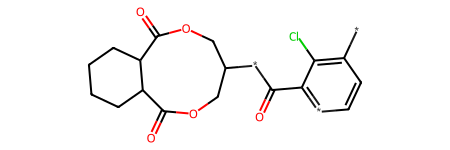

In [812]:
rwmol_
#TODO assign 2D coords

In [813]:
mol = rwmol_.GetMol()
mol.RemoveAllConformers()
conf = Chem.Conformer(mol.GetNumAtoms())
conf.Set3D(True)
for i, (x, y) in enumerate(heavy_centers):
    conf.SetAtomPosition(i, (x, y, 0))
mol.AddConformer(conf)
# Chem.SanitizeMol(mol)
Chem.AssignStereochemistryFrom3D(mol)
rwmol_=Chem.RWMol(mol) 
#as afte H also didthis

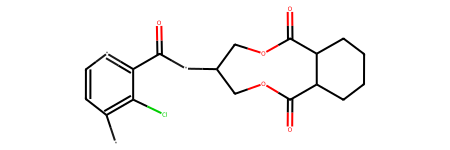

In [814]:
mol

In [815]:
#H realted post-process
#
heavyNumber=rwmol_.GetNumAtoms()
print(f'mol with heavy number atoms {heavyNumber}, max id {heavyNumber-1}')    
onlyHeayMol=copy.deepcopy(rwmol_)

Hais=[]
Hais_bt=[]
# H_existing_bonds = set()
for bi, ais in b2a.items():#from box overlap
    bt=bond_classes[bi]# in [14,15]#directon bond
    for ai in ais:
        if ai>heavyNumber-1:
            if bt in  [14,15]:#directon bond
                Hais.append(ais)#NOTE ais ai increasing order as two for loop increasing
                print(f"bond box id {bi} bond direction {idx_to_labels[bt]} atoms box id {ais} ")
                Hais_bt.append(idx_to_labels[bt])
                # print(bonds[bi] )


# add Hbonds with direction
H_existing_bonds = set()
ha2boxa=dict()
for ais, bt in zip(Hais,Hais_bt):
    idx_2=ais[-1]
    idx_1=ais[0]
    had = Chem.Atom("H")
    addHatom_idx = rwmol_.AddAtom(had)
    ha2boxa[addHatom_idx]=idx_2
    # print(idx_2,addHatom_idx)#Note if detected H box will lead idx_2 != addHatom_idx
    atom= rwmol_.GetAtomWithIdx(idx_1)
    max_val=max(VALENCES[atom.GetSymbol()])
    val = sum(b.GetBondTypeAsDouble() for b in atom.GetBonds())
    if (idx_1, addHatom_idx) not in H_existing_bonds and (addHatom_idx, idx_1) not in H_existing_bonds:
        if val<=max_val-1:
            # print(f"atom id {idx_1} val {val} max_val {max_val}")
            print(idx_1, addHatom_idx)
            # try:
            rwmol_.AddBond(idx_1,addHatom_idx, Chem.BondType.SINGLE)#BOND_DIRS[bt]
            b=rwmol_.GetBondBetweenAtoms(idx_1,addHatom_idx)
            b.SetBondDir(BOND_DIRS[bt])
            # except Exception as e:
            # print(f"erro@chiral_center_ids: {e}")
    H_existing_bonds.add((idx_1,addHatom_idx))
#remove islote H
# rwmol_=remove_unconnected_hydrogens(rwmol_)            



mol with heavy number atoms 26, max id 25
bond box id 27 bond direction BEGINDASH atoms box id [14, 27] 
bond box id 29 bond direction BEGINWEDGE atoms box id [17, 28] 
14 26
17 27


In [816]:
# conf=rwmol_.GetConformers()
rwmol_.RemoveAllConformers()
conf = Chem.Conformer(rwmol_.GetNumAtoms())
conf.Set3D(True)
conf.Set3D(True)
for i, (x, y) in enumerate(heavy_centers):
    conf.SetAtomPosition(i, (x, y, 0))
for k,v in ha2boxa.items():
    x,y=atom_centers[v]
    conf.SetAtomPosition(k, (x, y, 0))
rwmol_.AddConformer(conf)
rwmol_=remove_unconnected_hydrogens(rwmol_) #NOTE will dercease h atom,but the box have not updated TODO fix me this in feature activate learning

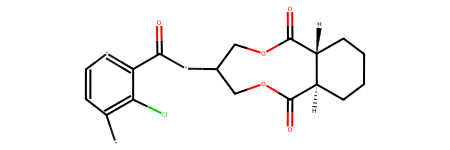

In [817]:
rwmol_

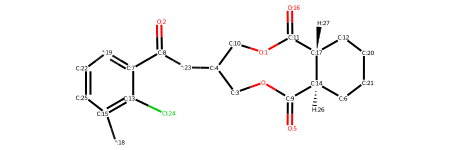

In [818]:
molIDX(copy.deepcopy(rwmol_))

In [308]:
# # 添加氢原子
# if h_centers.size > 0:
#     tree = KDTree(heavy_centers)
#     used_h = set()
#     for hi, h_center in enumerate(h_centers):
#         dists, idxs = tree.query(h_center,k=2)  # 找到最近的重原子
#         for dist, idx in zip(dists, idxs):
#             heavy_idx = heavy_idx_map[idx]
#             atom = rwmol_.GetAtomWithIdx(heavy_idx)
#             ats=atom.GetSymbol()
#             val = sum(b.GetBondTypeAsDouble() for b in atom.GetBonds())
#             max_val=max(VALENCES[ats])
#             # max_val = Chem.GetPeriodicTable().GetDefaultValence(atom.GetAtomicNum())
#             if val < max_val and hi not in used_h:
#                 h_atom = Chem.Atom('H')
#                 h_idx = rwmol_.AddAtom(h_atom)
#                 rwmol_.AddBond(heavy_idx, h_idx, Chem.BondType.SINGLE)
#                 used_h.add(hi)

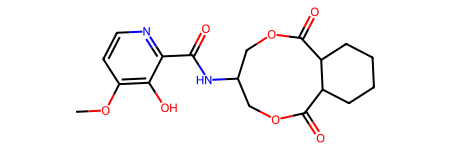

In [295]:
rwmol_

In [284]:
a2b

{0: [6, 23],
 1: [11, 25],
 2: [2, 18],
 3: [3],
 4: [10, 29],
 5: [22, 29],
 6: [8, 30],
 7: [14],
 8: [7, 8, 24],
 9: [26],
 10: [2, 5],
 11: [16],
 12: [17],
 13: [6, 12],
 14: [7, 22],
 15: [3, 4, 24],
 16: [1, 9, 21, 28],
 17: [11, 26, 27],
 18: [13, 20],
 19: [13, 19],
 20: [16, 20],
 21: [4, 10, 27],
 22: [30],
 23: [0, 15, 19, 21],
 24: [15, 17, 18],
 25: [9, 14, 23],
 26: [5, 12, 25],
 27: [0],
 28: [1, 14],
 29: [28]}

In [285]:
b2a

{0: [23, 27],
 1: [16, 28],
 2: [2, 10],
 3: [3, 15],
 4: [15, 21],
 5: [10, 26],
 6: [0, 13],
 7: [8, 14],
 8: [6, 8],
 9: [16, 25],
 10: [4, 21],
 11: [1, 17],
 12: [13, 26],
 13: [18, 19],
 14: [7, 25, 28],
 15: [23, 24],
 16: [11, 20],
 17: [12, 24],
 18: [2, 24],
 19: [19, 23],
 20: [18, 20],
 21: [16, 23],
 22: [5, 14],
 23: [0, 25],
 24: [8, 15],
 25: [1, 26],
 26: [9, 17],
 27: [17, 21],
 28: [16, 29],
 29: [4, 5],
 30: [6, 22]}

In [208]:
# """
# try to use mine below ways to buld mol from box
# """
# bonds_mask = np.array([True if ins  in bond_labels else False for ins in output['pred_classes']])
# bond_bbox=output['bbox'][bonds_mask]
# atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else False for ins in output['pred_classes']])
# atom_bbox=output['bbox'][atoms_mask]

# predict_boxes = output['bbox']
# newbox = predict_boxes #* [scale_x, scale_y, scale_x, scale_y]
# predict_classes = output['pred_classes']
# predict_scores = output['scores']
# charge_labels = [18,19,20,21,22]
            
# b2a=dict()
# for bi,bb in enumerate(bond_bbox):
#     overlapped_atoms = []
#     overlapped_abox=[]
#     for ai,aa in enumerate(atom_bbox):
#         overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
#         if overlap_flag:
#             # print(bb, aa,overlap_flag)
#             overlapped_atoms.append(ai)
#             overlapped_abox.append(aa)
#             if bi not in b2a.keys():
#                 b2a[bi]=[ai]
#             else:
#                 # vais=b2a[bi]
#                 b2a[bi].append(ai)
#     if len(overlapped_atoms) == 1:
#         print(f"single bond -atom still exists")


# a2b=dict()
# for ai,aa in enumerate(atom_bbox):
#     b_nei=[]
#     for bi,bb in enumerate(bond_bbox):
#         overlap_flag=boxes_overlap(bb, aa)#TODO use tghe atom bond box overlap get bond atom mapping,then built mol
#         if overlap_flag:
#             b_nei.append(bi)
#     a2b[ai]=b_nei
# #TODO build RDKIT RWMol from the atom_bbox bond_bbox


# #TODO merge charge box to atom box


In [ ]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])

print(f"atoms_df, bonds_list,charge_list::{[len(atoms_df), len(bonds_list),len(charge_list)]}")

SMILESpre,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


atoms_df, bonds_list,charge_list::[29, 30, 0]


In [91]:

#set bond direction again
wdbs=[b for b in bonds_list if b[3]=='BEGINDASH' or  b[3]=='BEGINWEDGE' ]
for b in wdbs:
    try:
        b_=mol_rebuit.GetBondBetweenAtoms(int(b[0]), int(b[1]))
        if b_:
            b_.SetBondDir(bond_dirs[b[3]])
    except Exception as e:
        print(e,"@@wdbs")
        print(b,f"\n{wdbs}")
        print(f"atoms_df@@{len(atoms_df)}")
        print(f"bonds_list@@{len(bonds_list)}")
        print(f"charge@@{len(charge_list)}")
        print(image_path)
        # print(SMILESori)
        # print(key,"@@key",[int(b[0]), int(b[1])])

aid_at={}
aid_at_star={}
for i_, row in atoms_df.iterrows():
    a_lab=row.atom[:-1]
    aid_at[i_]=a_lab
    #atom types not in defined vocable list
    if a_lab not in ['H', 'C', 'O', 'N', 'Cl', 'Br', 'S', 'F', 'B', 'I', 'P', 'Si']:#  '*', I2M's defined atom types
        aid_at_star[i_]="*"
            # aid_at[i_]=a_lab
    # print(aid_at,aid_at_star)
placeholder_atoms={k:aid_at[k] for k,v in aid_at_star.items() if aid_at[k] !='*' }

In [92]:
debug=True
if debug:
    import importlib
    importlib.reload(draw_box_utils)
    importlib.reload(src.solver.utils)
    from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral,assemble_atoms_with_charges
    from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text


In [ ]:
other2ppsocr=True
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']
charge_labels = [18,19,20,21,22]#make influence
bonds_mask = np.array([True if ins  in bond_labels else False 
                                for ins in output['pred_classes']])
bond_bbox=output['bbox'][bonds_mask]
atoms_mask = np.array([True if ins not in bond_labels and ins not in charge_labels else
                                False for ins in output['pred_classes']])
atom_bbox=output['bbox'][atoms_mask]

img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
print(w_ori, h_ori, "orignianl vs 1000,1000")
# 计算缩放比例
scale_x = 1000 / w_ori
scale_y = 1000 / h_ori
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
img_ac = copy.deepcopy(img)
newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
bondbox_only=newbox[bonds_mask]
b_predict_classes=predict_classes[bonds_mask]
b_predict_scores=predict_scores[bonds_mask]
#non bonds
acbox_only=newbox[~bonds_mask]
ac_predict_classes=predict_classes[~bonds_mask]
ac_predict_scores=predict_scores[~bonds_mask]

mol_rebuit = remove_unconnected_hydrogens(mol_rebuit)#
mol = rdkit.Chem.RWMol(mol_rebuit)
if other2ppsocr:
    print()
    need_cut=[]
    ppstr=[]
    ppstr_score=[]
    crops=[]
    index_token=dict()
    expan=-2#NOTE this control how much the part of bond in crop_Img
    # mol=deep.copy(mol_rebuit)
    # for i_, v in aidstart_rest.items():
    for i_, row in atoms_df.iterrows():
        if "*" in row.atom or "other" in row.atom or "Cl" in row.atom:
            need_cut.append(i_)
            a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
            box=a * [scale_x, scale_y, scale_x, scale_y]#TODO need the fix as w h may not equal!!
            # print(a,box,[scale_x, scale_y, scale_x, scale_y])
            cropped_img = img_ori_1k.crop(box)
            crops.append(cropped_img)
            image_npocr = np.array(cropped_img)
            result_ocr= ocr.ocr(image_npocr, det=False)
            s_, score_ =result_ocr[0][0]
            print(f'ocr::idx:{i_}',s_, score_ )
            if score_<=0.1:# process cropped_img and try again
                # print(s_, "xxx",score_)
                s_='*'
            if s_=='+' or s_=='-':
                s_="*"
            if len(s_)>1:
                s_=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', s_)#remove special chars
                if re.match(r'^\d+$', s_):
                    s_=f'{s_}*'#number+ *
                    # print(f'why only numbers ?  {s_}')
            if s_=='L':s_='Li'
            match = re.match(r'^(\d+)?(.*)', s_)
            # print(s_,'xxxx')
            if match:
                numeric_part, remaining_part = match.groups()
                fc_=mol.GetAtomWithIdx(i_).GetFormalCharge()
                if remaining_part in ELEMENTS:
                    new_atom = Chem.Atom(remaining_part)
                    mol.ReplaceAtom(i_, new_atom)
                    print(i_, remaining_part,"@@@")
                elif remaining_part in ABBREVIATIONS:# can be expanded with placeholder_atoms
                    placeholder_atoms[i_]=s_# such 2Na will be get for rdkit
                elif remaining_part=='OH':
                    new_atom = Chem.Atom("O")
                    mol.ReplaceAtom(i_, new_atom)
                elif remaining_part=='SH':
                    new_atom = Chem.Atom("S")
                    mol.ReplaceAtom(i_, new_atom)
                elif remaining_part=='NH':
                    new_atom = Chem.Atom("N")
                    mol.ReplaceAtom(i_, new_atom)
                mol.GetAtomWithIdx(i_).SetFormalCharge(fc_)
                # else:
                #     if numeric_part:
                #         s_=f'{numeric_part}*'
                #     else:
                #         s_='*'
            index_token[i_]=f'{s_}:{i_}'
            print(f"idx:{i_}, atm: <{row.atom}> --- [{s_}:{i_}] with score:{score_}")
            
            mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")#mol set with label, mol_rebuild not
            ppstr.append(s_)
            ppstr_score.append(score_)
            if s_ in ELEMENTS or s_ in ABBREVIATIONS.keys():
                placeholder_atoms[i_]=s_

if len(placeholder_atoms)>0:
    print(placeholder_atoms)
    expandStero_smi,molexp= molExpanding(mol,placeholder_atoms,wdbs,bond_dirs)#TODO fix me whe n multi strings on a atom will missing this ocr infors
    molexp = remove_unconnected_hydrogens(molexp)

else:
    molexp=mol
    expandStero_smi=SMILESpre

boxed_img = draw_objs(img_ac,
                        # newbox,
                        # predict_classes,
                        # predict_scores,
                        acbox_only,
                        ac_predict_classes,
                        ac_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

boxed_img_b = draw_objs(img,
                        bondbox_only,
                        b_predict_classes,
                        b_predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)


634 323 orignianl vs 1000,1000

ocr::idx:18 OMe 0.9914911389350891
idx:18, atm: <*0> --- [OMe:18] with score:0.9914911389350891


ocr::idx:19 N 0.9950695037841797
19 N @@@
idx:19, atm: <other0> --- [N:19] with score:0.9950695037841797
ocr::idx:23 N 0.9917877316474915
23 N @@@
idx:23, atm: <other0> --- [N:23] with score:0.9917877316474915
ocr::idx:24 OH 0.9766774773597717
idx:24, atm: <Cl0> --- [OH:24] with score:0.9766774773597717
{19: 'N', 23: 'N', 18: 'OMe'}


In [94]:
print(len(atoms_df),len(bonds_list),len(charge_list)),index_token

29 30 0


(None, {18: 'OMe:18', 19: 'N:19', 23: 'N:23', 24: 'OH:24'})

In [95]:
# # 方法 1: 清除芳香性标记并重新计算
# for bond in molexp.GetBonds():
#     bond.SetIsAromatic(False)
# for atom in molexp.GetAtoms():
#     atom.SetIsAromatic(False)

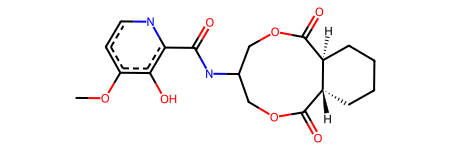

In [ ]:
molexp

In [97]:
smi=Chem.MolToSmiles(molexp)
smi

'[H][C@]12CCCC[C@]1([H])C(=O)OCC(NC(=O)c1c(O)c(OC)ccN1)COC2=O'

In [98]:
s="[H][C@]12CCCC[C@]1([H])C(=O)OCC(NC(=O)C1=NC=CC(OC)=C1O)COC2=O"
m1=Chem.MolFromSmiles(s)
smi2=Chem.MolToSmiles(m1)
smi2

'COc1ccnc(C(=O)NC2COC(=O)[C@H]3CCCC[C@@H]3C(=O)OC2)c1O'

In [99]:
original_smiles,test_smiles=s,smi
original_smiles = remove_backslash_and_slash(original_smiles)#c/s 
test_smiles = remove_backslash_and_slash(test_smiles)
original_smiles = re.sub(r'\[(\d+)\*', '[*',original_smiles)#[1*]-->[*]
test_smiles = re.sub(r'\[(\d+)\*', '[*',test_smiles)
original_smiles = remove_SP(original_smiles)#additional complex space stero from coordinates, most not used
test_smiles = remove_SP(test_smiles)
rd_smi_ori, success1=rdkit_canonicalize_smiles(original_smiles)
rd_smi, success2=rdkit_canonicalize_smiles(test_smiles)
original_smiles,test_smiles=rd_smi_ori,rd_smi

NameError: name 'remove_backslash_and_slash' is not defined

In [100]:
success1,success2

NameError: name 'success1' is not defined

In [101]:
#acc
from src.solver.det_engine import remove_backslash_and_slash, rdkit_canonicalize_smiles

In [102]:
def comparing_smiles2(original_smiles,test_smiles):
    original_smiles = remove_backslash_and_slash(original_smiles)#c/s 
    test_smiles = remove_backslash_and_slash(test_smiles)
    original_smiles = re.sub(r'\[(\d+)\*', '[*',original_smiles)#[1*]-->[*]
    test_smiles = re.sub(r'\[(\d+)\*', '[*',test_smiles)
    original_smiles = remove_SP(original_smiles)#additional complex space stero from coordinates, most not used
    test_smiles = remove_SP(test_smiles)
    rd_smi_ori, success1=rdkit_canonicalize_smiles(original_smiles)
    rd_smi, success2=rdkit_canonicalize_smiles(test_smiles)
    original_smiles,test_smiles=rd_smi_ori,rd_smi
    try:
        original_mol = Chem.MolFromSmiles(original_smiles)#considering whe nmmet abbrev
        test_mol = Chem.MolFromSmiles(test_smiles,sanitize=False)#as build mol may not sanitized for rdkit
        if original_mol:
            Chem.SanitizeMol(original_mol)
            keku_smi_ori=Chem.MolToSmiles(original_mol,kekuleSmiles=True)
        else:
            keku_smi_ori=original_smiles
        
        if test_mol:
            Chem.SanitizeMol(test_mol)
            keku_smi=Chem.MolToSmiles(test_mol,kekuleSmiles=True)
        else:
            keku_smi=test_smiles
            
        if '*' not in keku_smi:
            keku_inch_ori=  Chem.MolToInchi(Chem.MolFromSmiles(keku_smi_ori))
            keku_inch_test=  Chem.MolToInchi(Chem.MolFromSmiles(keku_smi))
        else:
            keku_inch_ori=  1
            keku_inch_test=  2

        rd_smi=Chem.MolToSmiles(test_mol)#need improve the acc
        rd_smi_ori=Chem.MolToSmiles(original_mol)
    except Exception as e:#TODO fixme here
        print(f"comparing_smiles@@@ kekulize or SanitizeMol problems")# original_smiles,test_smiles\n{original_smiles}\n{test_smiles}")
        print(new_row)
        print(e,"!!!!!!!\n")
        keku_inch_ori=  1
        keku_inch_test=  2
        keku_smi=1
        keku_smi_ori=2
        #add molscribe rules here
        if not success1:#ori smiles still invaild even after * replaced
            rd_smi_ori = rd_smi
        # else:
        #     if canon_smiles1 == canon_smiles2:
        #         rd_smi_ori = rd_smi
            # else:
    if rd_smi_ori == rd_smi or keku_smi_ori == keku_smi or keku_inch_ori==keku_inch_test :#as orinial smiles may use kekuleSmiles style
        return True
    else:return False

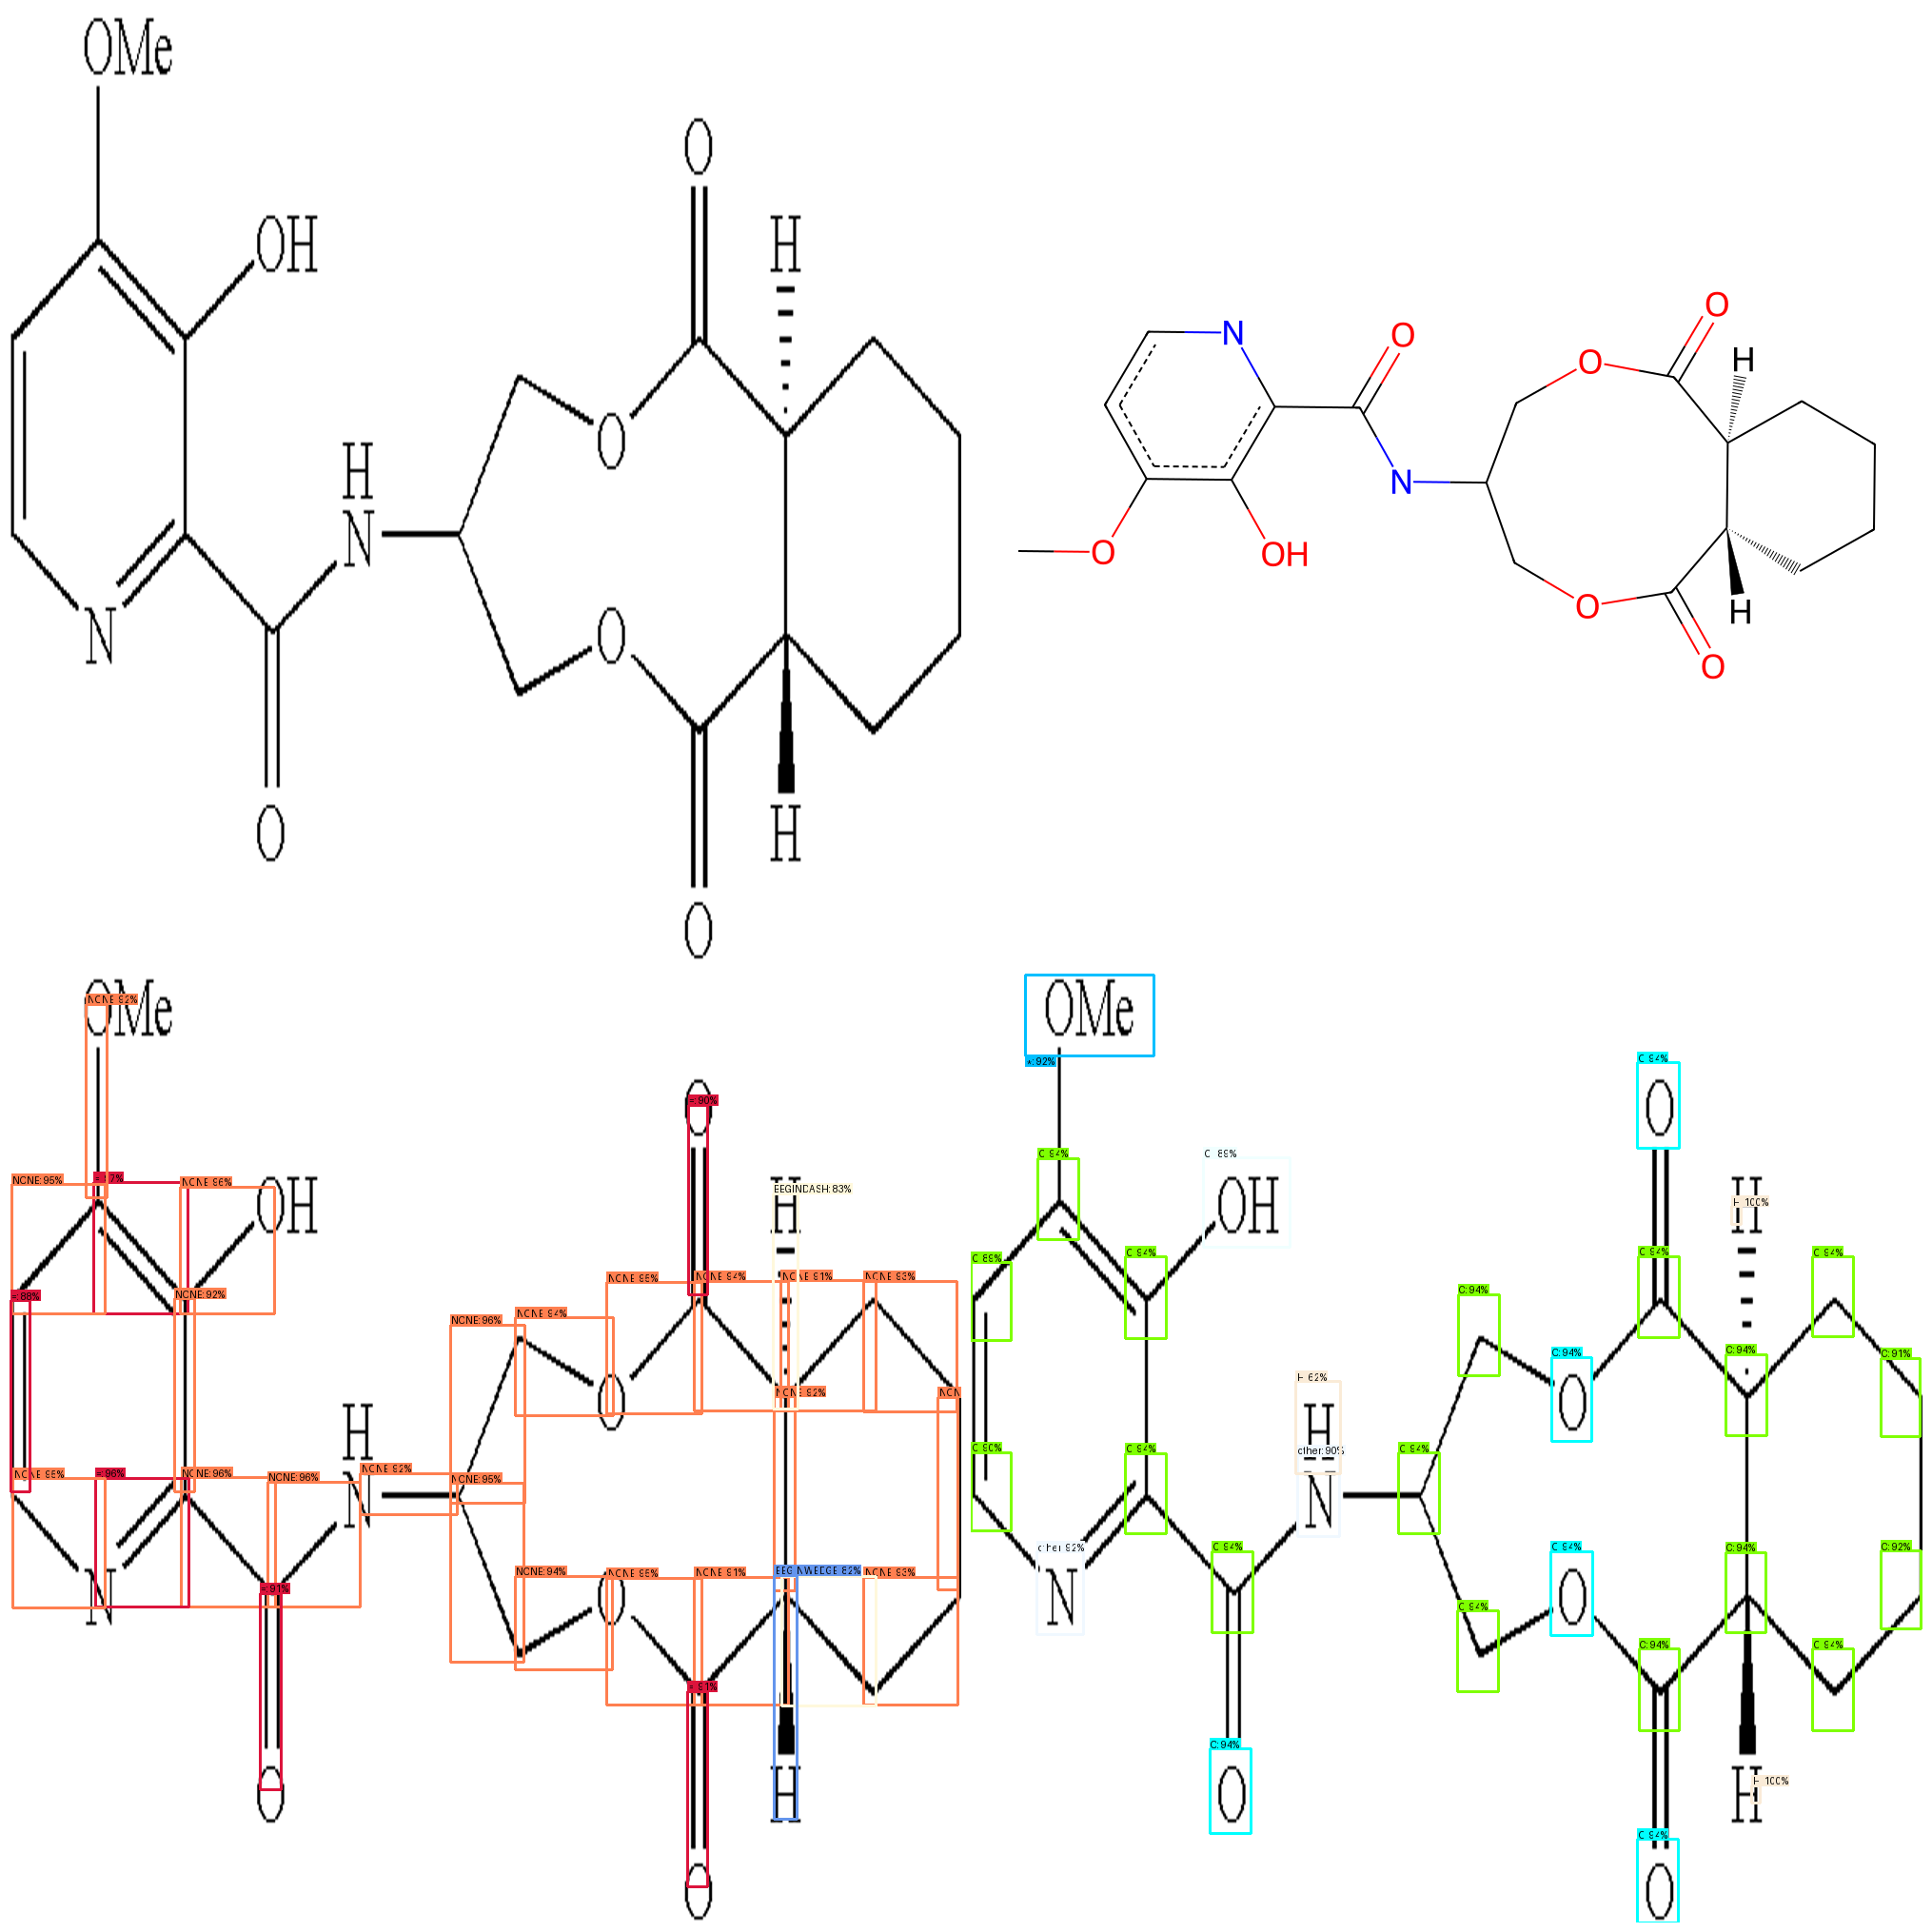

In [ ]:
visual_check=True
other2ppsocr=True
# TODO #[3H] 2H prpared box for training are too smalled, need adjust
if visual_check:
    padding = 10  # You can adjust this value for more or less space
    img_ori = Image.open(image_path).convert('RGB')
    img_ori_1k = img_ori.resize((1000,1000))
    if other2ppsocr:
        img_rebuit = Draw.MolToImage(molexp, options=opts,size=(1000, 1000))
    else:
        img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
    # Create the 2x2 grid: total width and height for the new image
    # combined_img = Image.new('RGB', (1000 * 2, 1000 * 2))
    # # Paste images in the corresponding positions:
    # combined_img.paste(img_ori_1k, (0, 0))  # Top-left
    # combined_img.paste(img_rebuit, (0, 1000))  # Bottom-left
    # combined_img.paste(boxed_img, (1000, 0))  # Top-right
    # combined_img.paste(boxed_img_b, (1000, 1000))  # Bottom-right        
    # Define padding size
    # Create the 2x2 grid with padding
    combined_img = Image.new('RGB', (1000 * 2 + padding * 3, 1000 * 2 + padding * 3), color=(255, 255, 255))  # White background
    combined_img.paste(img_ori_1k, (padding, padding))  # Top-left
    combined_img.paste(img_rebuit, (1000 + padding * 2, padding))  # Top-right
    combined_img.paste(boxed_img_b, (padding, 1000 + padding * 2))  # Bottom-left
    combined_img.paste(boxed_img, (1000 + padding * 2, 1000 + padding * 2))  # Bottom-right
combined_img

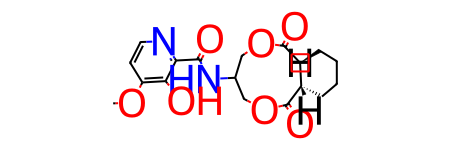

In [81]:
mol_rebuit

In [220]:
"""
image_path="/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png"
real image: OH as  Cl  with 89% score

"""

'\nimage_path="/home/jovyan/rt-detr/data/real/USPTO/USRE039991-20080101-C00272.png"\nreal image: OH as  Cl  with 89% score\n\n'

In [140]:
new_row = {'file_name':image_path, 
#  "SMILESori":SMILESori,
        'SMILESpre':SMILESpre,#with *  without expand
        'SMILESexp':expandStero_smi, 
        }
smiles_data = smiles_data._append(new_row, ignore_index=True)

In [141]:
smiles_data

,file_name,SMILESori,SMILESpre,SMILESexp
0,/home/jovyan/volume/samba_share/from_docker/da...,NaN,***1=*(*)*(*(=*)**2***3=*[*@@]34****[*@@]43*=*...,***1=*(*)*(*(=*)**2***3=*[*@@]34****[*@@]43*=*...


In [142]:
print("atomMap,rmsd2",atomMap,rmsd2)
print("now after AlignMol  target_mol 2d coords changed!!")
conformer = target_mol.GetConformer()
# 获取每个原子的坐标
atom_positions = {i: conformer.GetAtomPosition(i) for i in range(target_mol.GetNumAtoms())}
# 打印原子坐标
for idx, pos in atom_positions.items():
    a=target_mol.GetAtomWithIdx(idx)
    elem=a.GetSymbol()
    print(f"Atom {idx}   {elem}: (x={pos.x:.3f}, y={pos.y:.3f}, z={pos.z:.3f})")

NameError: name 'atomMap' is not defined

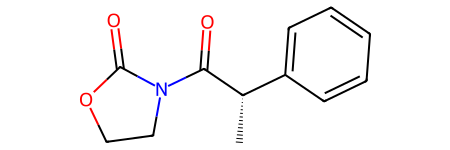

In [68]:
# Chem.SanitizeMol(target_mol)
# Chem.DetectBondStereochemistry(target_mol)
# Chem.AssignChiralTypesFromBondDirs(target_mol)
# Chem.AssignStereochemistry(target_mol)
target_mol#with MCS highlight
expandStero_smi=Chem.MolToSmiles(target_mol)#directly will not add the stero info into smiles, must have the assing steps
m=target_mol.GetMol()
Chem.SanitizeMol(m)
Chem.DetectBondStereochemistry(m)
Chem.AssignChiralTypesFromBondDirs(m)
Chem.AssignStereochemistry(m)
m#without hihglight

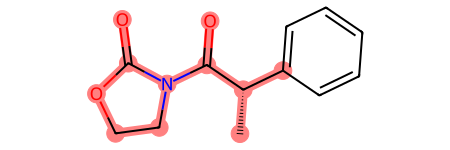

In [67]:
target_mol#with MCS highlight

In [64]:
Chem.MolToSmiles(m)

'C[C@H](C(=O)N1CCOC1=O)c1ccccc1'

0
1
2
3
4
5
6
7
8
9
10


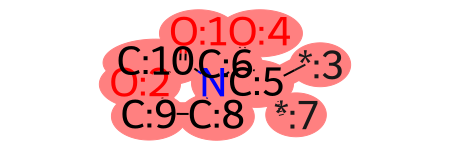

In [252]:
molIDX(ref_mol)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


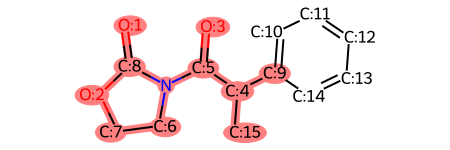

In [253]:
molIDX(target_mol)

In [238]:
conformer = ref_mol.GetConformer()
# 获取每个原子的坐标
atom_positions = {i: conformer.GetAtomPosition(i) for i in range(ref_mol.GetNumAtoms())}
# 打印原子坐标
for idx, pos in atom_positions.items():
    a=ref_mol.GetAtomWithIdx(idx)
    elem=a.GetSymbol()
    print(f"Atom {idx}   {elem}: (x={pos.x:.3f}, y={pos.y:.3f}, z={pos.z:.3f})")

Atom 0   N: (x=0.963, y=2.070, z=0.000)
Atom 1   O: (x=0.561, y=2.770, z=0.000)
Atom 2   O: (x=0.220, y=2.074, z=0.000)
Atom 3   *: (x=2.222, y=2.311, z=0.000)
Atom 4   O: (x=1.365, y=2.770, z=0.000)
Atom 5   C: (x=1.780, y=2.081, z=0.000)
Atom 6   C: (x=1.359, y=2.325, z=0.000)
Atom 7   *: (x=1.894, y=1.623, z=0.000)
Atom 8   C: (x=0.789, y=1.634, z=0.000)
Atom 9   C: (x=0.312, y=1.637, z=0.000)
Atom 10   C: (x=0.546, y=2.368, z=0.000)


In [239]:
atoms_df# x/100 ,y/100 scaled

,atom,x,y,bbox,scores
0,N0,96.336494,93.049988,"[78.72564697265625, 75.7518081665039, 113.9473...",0.940527
1,O0,56.051975,23.014444,"[38.385009765625, 4.699044704437256, 73.718940...",0.911322
2,O0,22.033363,92.618912,"[4.997264862060547, 74.24376678466797, 39.0694...",0.910625
3,Me0,222.230621,68.941017,"[190.7293243408203, 51.65073013305664, 253.731...",0.910046
4,O0,136.467926,22.984482,"[118.59431457519531, 4.907514572143555, 154.34...",0.896478
5,C0,177.972717,91.940117,"[161.32281494140625, 74.89513397216797, 194.62...",0.890144
6,C0,135.924103,67.492584,"[119.90592956542969, 50.09312438964844, 151.94...",0.865667
7,Ph0,189.373474,137.706116,"[164.1694793701172, 119.6893539428711, 214.577...",0.851300
8,C0,78.940117,136.581589,"[62.81029510498047, 119.77143096923828, 95.069...",0.843375
9,C0,31.162994,136.343765,"[14.961268424987793, 119.18004608154297, 47.36...",0.837119


In [240]:
bonds_list

[(6, 5, 'SINGLE', 'NONE', 0.9123611),
 (10, 0, 'SINGLE', 'NONE', 0.9023442),
 (2, 10, 'SINGLE', 'NONE', 0.8987796),
 (0, 6, 'SINGLE', 'NONE', 0.88877493),
 (5, 3, 'SINGLE', 'NONE', 0.8873214),
 (8, 0, 'SINGLE', 'NONE', 0.86127347),
 (2, 9, 'SINGLE', 'NONE', 0.84059596),
 (9, 8, 'SINGLE', 'NONE', 0.8339964),
 (1, 10, 'DOUBLE', '=', 0.814472),
 (4, 6, 'DOUBLE', '=', 0.81146896),
 (5, 7, 'SINGLE', 'BEGINDASH', 0.6908535)]

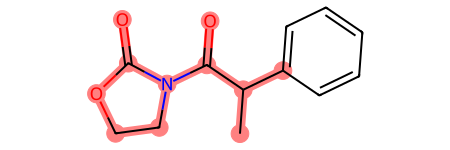

In [241]:
target_mol

In [242]:
#now after AlignMol  target_mol 2d coords changed
conformer = target_mol.GetConformer()
# 获取每个原子的坐标
atom_positions = {i: conformer.GetAtomPosition(i) for i in range(target_mol.GetNumAtoms())}
# 打印原子坐标
for idx, pos in atom_positions.items():
    a=target_mol.GetAtomWithIdx(idx)
    elem=a.GetSymbol()
    print(f"Atom {idx}   {elem}: (x={pos.x:.3f}, y={pos.y:.3f}, z={pos.z:.3f})")

Atom 0   N: (x=0.678, y=2.078, z=0.000)
Atom 1   O: (x=-0.845, y=4.275, z=0.000)
Atom 2   O: (x=-1.727, y=1.752, z=0.000)
Atom 3   O: (x=2.141, y=4.225, z=0.000)
Atom 4   C: (x=3.269, y=1.885, z=0.000)
Atom 5   C: (x=2.029, y=2.729, z=0.000)
Atom 6   C: (x=0.410, y=0.602, z=0.000)
Atom 7   C: (x=-1.076, y=0.401, z=0.000)
Atom 8   C: (x=-0.643, y=2.789, z=0.000)
Atom 9   C: (x=4.620, y=2.536, z=0.000)
Atom 10   C: (x=4.732, y=4.032, z=0.000)
Atom 11   C: (x=6.083, y=4.683, z=0.000)
Atom 12   C: (x=7.322, y=3.838, z=0.000)
Atom 13   C: (x=7.211, y=2.343, z=0.000)
Atom 14   C: (x=5.859, y=1.691, z=0.000)
Atom 15   C: (x=3.157, y=0.389, z=0.000)


In [99]:
target_mol = Chem.MolFromSmiles("CCOc1ccc(CCNC(=O)C2CCCCC2)cc1")
# 生成目标分子的 2D 坐标
AllChem.Compute2DCoords(target_mol)
# 使用 SMARTS 定义模糊匹配结构（苯环+任意链式连接）
ref_mol = Chem.MolFromSmarts("c1ccc(*)cc1")  # * 代表任意连接点
# 计算 2D 坐标
Chem.rdDepictor.Compute2DCoords(ref_mol)

# 生成 2D 结构，匹配固定部分
AllChem.GenerateDepictionMatching2DStructure(target_mol, ref_mol)

((0, 3), (1, 4), (2, 5), (3, 6), (4, 7), (5, 18), (6, 19))

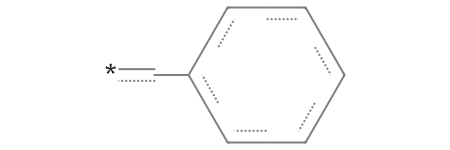

In [101]:
ref_mol

In [46]:
from rdkit.Chem import rdFMCS as _rdFMCS


Query *C(*)C(=O)N1CCOC1=O 11(6) atoms, 11(4) bonds
1 Seeds:5 MCS 5 atoms, 4 bonds for 0.0006 seconds. bond[0]=0
STATISTICS:
Total Growing Steps  = 1, MCS found on 1 step, for 0.0006 seconds
Initial   Seeds      = 11,  Mismatched 7
Inspected Seeds      = 12
Rejected by BestSize = 0
IndividualBondExcluded   = 0
MatchCheck Seeds     = 12
     MatchCalls = 9
     MatchFound = 2
 fastMatchCalls = 1
 fastMatchFound = 1
 slowMatchCalls = 8
 slowMatchFound = 1
  DupCacheFound = 0   0 matched, 0 mismatched
HashCache size  = 2 keys
HashCache size  = 2 entries
FindHashInCache = 12
HashFoundInCache= 10
ExactMatchCalls = 10
ExactMatchFound = 3


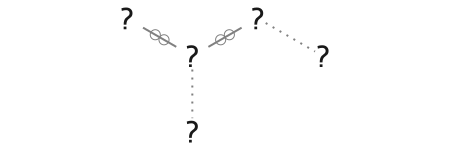

In [ ]:
mcs = _rdFMCS.FindMCS([cm,rdm],  # larger,small order
                atomCompare=rdkit.Chem.rdFMCS.AtomCompare.CompareAny,
                bondCompare=rdkit.Chem.rdFMCS.BondCompare.CompareAny,
                ringCompare=rdkit.Chem.rdFMCS.RingCompare.IgnoreRingFusion,
                completeRingsOnly=True,
                ringMatchesRingOnly=True,
                matchChiralTag=True,
                matchValences=True,
                maximizeBonds=False,
                threshold=1.0,verbose=True,timeout=120 )
# mcs.smartsString
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
mcs_mol

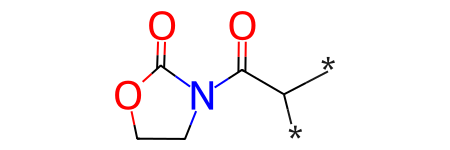

In [84]:
cm

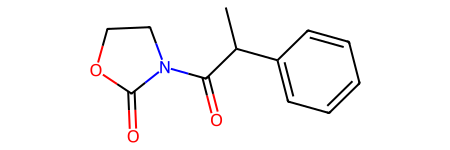

In [85]:
rdm

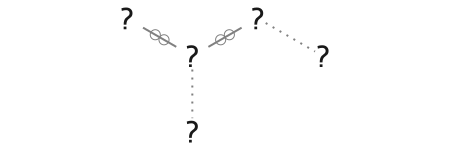

In [86]:
# mcs.smartsString
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
mcs_mol

In [51]:
mcs.smartsString

'[#6&!R](-&!@[#6&!R])=&!@[#8&!R]'

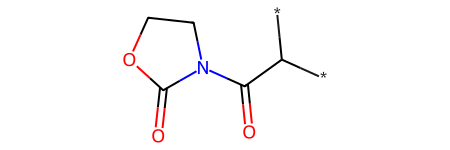

In [ ]:
sma_cm=Chem.MolToSmarts(cm)
Chem.MolFromSmarts(sma_cm)

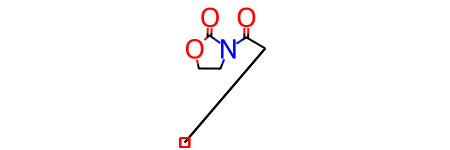

In [53]:
modified_mol

In [54]:
# 生成 2D 坐标
AllChem.Compute2DCoords(modified_mol)

0

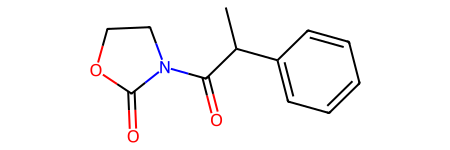

In [ ]:
modified_mol

In [ ]:
modified_smiles

'CC(C(=O)N1CCOC1=O)c1ccccc1'

In [57]:
import io
from xml.dom import minidom


In [58]:
def molIDX(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(i)  #映射
        print(i)
    return mol

def molIDX_del(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(0)  #映射
        print(i)
    return mol

In [59]:
aid_at

{0: 'N',
 1: 'O',
 2: 'O',
 3: 'Me',
 4: 'O',
 5: 'C',
 6: 'C',
 7: 'Ph',
 8: 'C',
 9: 'C',
 10: 'C'}

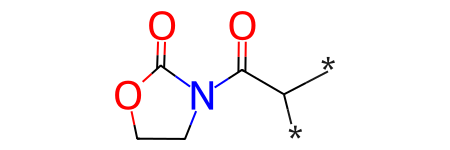

In [ ]:
cm=copy.deepcopy(mol_rebuit)
# molIDX(cm)
cm

In [ ]:
from SmilesPE.pretokenizer import atomwise_tokenizer
print(Chem.MolToSmiles(cm))
atomwise_tokenizer(Chem.MolToSmiles(cm))

*C(*)C(=O)N1CCOC1=O


['*',
 'C',
 '(',
 '*',
 ')',
 'C',
 '(',
 '=',
 'O',
 ')',
 'N',
 '1',
 'C',
 'C',
 'O',
 'C',
 '1',
 '=',
 'O']

In [ ]:
aa=Chem.MolFromSmiles("[N:0]1([C:6](=[O:4])[CH:5]([Me:3])[*:7])[CH2:8][CH2:9][O:2][C:10]1=[O:1]",sanitize=False)

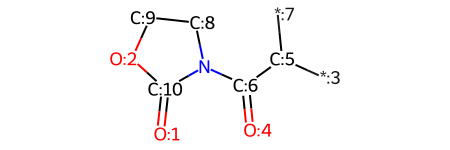

In [ ]:
Chem.MolFromSmiles("N1([C:6](=[O:4])[CH:5]([*:3])[*:7])[CH2:8][CH2:9][O:2][C:10]1=[O:1]")

In [64]:
from rdkit import Chem
from rdkit.Chem import Draw
from xml.dom import minidom

def wh_get_svg_doc(mol, wh=[300, 300], writeSVG=False, fontSize=12):
    width, height = wh
    # 初始化绘图器
    d2d_svg = Chem.Draw.MolDraw2DSVG(width, height)
    options = d2d_svg.drawOptions()
    options.useBWAtomPalette()  # 使用黑白原子调色板
    dm = Draw.PrepareMolForDrawing(mol)
    d2d_svg.DrawMolecule(dm)
    d2d_svg.AddMoleculeMetadata(dm)
    d2d_svg.FinishDrawing()
    
    # 获取图像缓冲区
    base_svg = d2d_svg.GetDrawingText()
    
    # 手动修改 SVG 中的字体大小
    doc = minidom.parseString(base_svg)
    text_elements = doc.getElementsByTagName("text")
    for text in text_elements:
        text.setAttribute("font-size", str(fontSize))
    
    # 将修改后的 SVG 转换为字符串
    modified_svg = doc.toxml()
    
    if writeSVG:
        with open(f"{writeSVG}_view.svg", "w") as file:
            file.write(modified_svg)
    
    return modified_svg, doc, wh

In [ ]:
base_svg,doc,wh=wh_get_svg_doc(cm,wh=[300,300],writeSVG=True,fontSize=20)
rdkSVGatms=[path.getAttribute('atom-smiles') for path in doc.getElementsByTagName('rdkit:atom')]
rdkSVGatms

['[N]',
 '[O]',
 '[O]',
 '[*]',
 '[O]',
 '[CH]',
 '[C]',
 '[*]',
 '[CH2]',
 '[CH2]',
 '[C]']

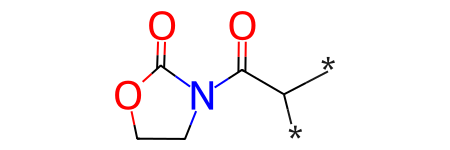

In [66]:
cm

In [67]:
t_scores=np.ones(10)
t_scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [68]:
print(img_ori.size)

(258, 159)


In [69]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


need_cut=[]
ppstr=[]
ppstr_score=[]
crops=[]
index_token=dict()
expan=8#NOTE this control how much the part of bond in crop_Img
mol = rdkit.Chem.RWMol(mol_rebuit)
other2pps=False

# for i_, atom_s in enumerate(atom_df['atom']):
for i_, row in atoms_df.iterrows():
    if "*" in row.atom or "other" in row.atom:
        need_cut.append(i_)
        a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
        box=a * 10/3
        cropped_img = img_ori_1k.crop(box)
        crops.append(cropped_img)
        # Show the cropped image
        # cropped_img.show()
        # cropped_img.save('box_crop01.jpg')
        # Convert PIL Image to a numpy array
        image_np = np.array(cropped_img)
        result = ocr.ocr(image_np, det=False)
        s_, score_ =result[0][0]
        if score_<=0.1:# process cropped_img and try again
            print(s_, "xxx",score_)
            s_='*'
        if s_=='+' or s_=='-':
            s_="*"
        if len(s_)>1:
            s_=re.sub(r'[^a-zA-Z0-9]', '', s_)#remove special chars
            if re.match(r'^\d+$', s_):print(f'why only numbers ?  {s_}')

        index_token[i_]=f'{s_}:{i_}'
        print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
        mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

        ppstr.append(s_)
        ppstr_score.append(score_)

In [70]:
from PIL import Image, ImageFilter,ImageEnhance


In [ ]:
pil_l=cropped_img.convert("L")
# binarized_img = pil_l.point(lambda x: 255 if x > 150 else 0, mode="1")
sharpen_kernel = [
    -1, -1, -1,
    -1,  9, -1,
    -1, -1, -1
]
sharpness_factor=2.0
# 应用锐化滤波器
sharpened_img = pil_l.filter(ImageFilter.Kernel((3, 3), sharpen_kernel, scale=1, offset=0))
# 增强锐度
enhancer = ImageEnhance.Sharpness(sharpened_img)
enhanced_img = enhancer.enhance(sharpness_factor)

NameError: name 'cropped_img' is not defined

In [142]:
0.9909*4173

4135.0257

In [143]:
44516/46285

0.9617802743869505

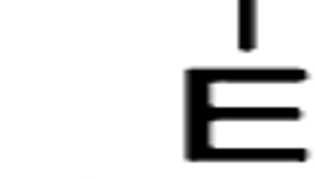

In [36]:
cropped_img#TODO 对于* 未知box trained 太小

In [126]:
a=Chem.MolFromSmiles('[2Na]')
type(a)

rdkit.Chem.rdchem.Mol

In [110]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit
need_cut=[]
ppstr=[]
ppstr_score=[]
crops=[]
index_token=dict()
expan=8#NOTE this control how much the part of bond in crop_Img
mol = rdkit.Chem.RWMol(mol_rebuit)
other2pps=False

print(smiles)
# for i_, atom_s in enumerate(atom_df['atom']):
iiii=0
for i_, row in atoms_df.iterrows():
    iiii+=1
    if "*" in row.atom or "other" in row.atom:
        need_cut.append(i_)
        a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
        box=a * 10/3
        cropped_img = img_ori_1k.crop(box)
        crops.append(cropped_img)
        # Show the cropped image
        # cropped_img.show()
        # cropped_img.save('box_crop01.jpg')
        # Convert PIL Image to a numpy array
        image_np = np.array(cropped_img)
        result = ocr.ocr(image_np, det=False)
        s_, score_ =result[0][0]
        print(s_, score_,"xxxxxxxxxx")
        if score_<=0.1:# process cropped_img and try again
                print(s_, "xxx",score_)
                s_='*'
        if s_=='+' or s_=='-':
            s_="*"
        if len(s_)>1:
            s_=re.sub(r'[^a-zA-Z0-9]', '', s_)#remove special chars
            if re.match(r'^\d+$', s_):print(f'why only numbers ?  {s_}')
        if s_=='L':s_='Li'
        print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
        mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

        ppstr.append(s_)
        ppstr_score.append(score_)
# print(f"nums: {len(index_token)} '*' need paddleOCR converting",index_token)
final_mol = mol.GetMol()
# except Exception as e:
#     print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
#     print(atoms_df)
#     print(image_path,"@@atoms_df for loop")
#     print(e)
#     uncorrects.append(image_path)
    # continue


rdkit_input_s=Chem.MolToSmiles(Chem.MolFromSmiles(input_s),kekuleSmiles=True)
if len(ppstr)==1:
    #just replace * with []
    cur_smi=Chem.MolToSmiles(final_mol,kekuleSmiles=True)#as csv use kekuleSmiles style
    match = re.match(r'^(\d+)?(.*)', s_)
    if match:
        numeric_part, remaining_part = match.groups()
        if remaining_part in chemical_elements:
            s_=s_
        else:
            s_='*'
    test_smiles=re.sub(r'\*', f'[{s_}]', cur_smi)
    print(cur_smi,test_smiles)
    # new_mol=Chem.MolFromSmiles(test_smiles)
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append([image_path])

    other2pps=True  
elif len(ppstr)>1:
    index_mol=copy.deepcopy(final_mol)
    show_atom_number(index_mol, 'molAtomMapNumber')
    index_smi=Chem.MolToSmiles(index_mol)
    ai_tokens=atomwise_tokenizer(index_smi)
    new_toks=[]
    for k,v in index_token.items():
        for i, atoken in enumerate(ai_tokens):
            if f':{k}' in atoken:
                # index_token[k]
                ai_tokens[i]=re.sub(r'\[.*?\]', f'[{index_token[k]}]', ai_tokens[i])
                print(f':{k},  {atoken} --> [{index_token[k]}] || {ai_tokens[i]}' )
            # new_toks.append(atoken)
    new_smi=''.join(ai_tokens)
    new_mol=Chem.MolFromSmiles(new_smi)#if str not belong chemical_elements will failed
    m_noid=remove_atom_number(new_mol)
    s_noid=Chem.MolToSmiles(m_noid)
    test_smiles = re.sub(r'\[(\d+)\*', '[*',s_noid)#remove_number_before_star
    test_smiles = remove_SP(test_smiles)
    # input_s='[*]C1([*])*[W]CN(S(=O)(=O)C2=CC=C(O[Ar])C=C2)C1C(=O)NO'
    other2pps=True
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append(image_path)
else:
    uncorrects.append(image_path)
    other2pps=False
# except Exception as e:
#     other2pps=False
#     uncorrects.append(image_path)
#     print(f"not recongnized::{image_path}\n")
#     print(e)

*CC1=CC(=O)CCC1
 0.0 xxxxxxxxxx
 xxx 0.0
idx:7, atm:*0-->[*:7] with score:0.0
*CC1=CC(=O)CCC1 [*]CC1=CC(=O)CCC1


In [38]:
match = re.match(r'^(\d+)?(.*)', "Ar-")
numeric_part, remaining_part = match.groups()

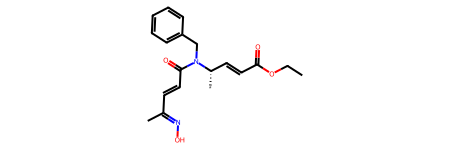

In [39]:
Chem.MolFromSmiles('[*][C@@H](C=CC(=O)OCC)N(Cc1ccccc1)C(=O)C=CC(C)=NO')

In [40]:
try:
    atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                        bond_labels=bond_labels,  result=[])
    smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


    need_cut=[]
    ppstr=[]
    ppstr_score=[]
    crops=[]
    index_token=dict()
    expan=8#NOTE this control how much the part of bond in crop_Img
    mol = rdkit.Chem.RWMol(mol_rebuit)
    other2pps=False

    # for i_, atom_s in enumerate(atom_df['atom']):
    for i_, row in atoms_df.iterrows():
        if "*" in row.atom or "other" in row.atom:
            need_cut.append(i_)
            a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
            box=a * 10/3
            cropped_img = img_ori_1k.crop(box)
            crops.append(cropped_img)
            image_np = np.array(cropped_img)
            result = ocr.ocr(image_np, det=False)
            s_, score_ =result[0][0]
            print(f'ocr::idx:{i_}',s_, score_ )
            if score_<=0.1:# process cropped_img and try again
                    print(s_, "xxx",score_)
                    s_='*'
            if s_=='+' or s_=='-':
                s_="*"
            if len(s_)>1:
                s_=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', s_)#remove special chars
                if re.match(r'^\d+$', s_):
                    s_=f'{s_}*'#number+ *
                    print(f'why only numbers ?  {s_}')
            if s_=='L':s_='Li'
            match = re.match(r'^(\d+)?(.*)', s_)
            if match:
                numeric_part, remaining_part = match.groups()
                if remaining_part in chemical_elements:
                    s_=s_
                else:
                    if numeric_part:
                        s_=f'{numeric_part}*'
                    else:
                        s_='*'
            index_token[i_]=f'{s_}:{i_}'
            print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
            mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

            ppstr.append(s_)
            ppstr_score.append(score_)
    # print(f"nums: {len(index_token)} '*' need paddleOCR converting",index_token)
    final_mol = mol.GetMol()
except Exception as e:
    print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
    print(atoms_df)
    print(image_path,"@@atoms_df for loop")
    print(e)
    uncorrects.append(image_path)
    # continue


rdkit_input_s=Chem.MolToSmiles(Chem.MolFromSmiles(input_s),kekuleSmiles=True)
if len(ppstr)==1:
    #just replace * with []
    cur_smi=Chem.MolToSmiles(final_mol,kekuleSmiles=True)#as csv use kekuleSmiles style
    test_smiles=re.sub(r'\*', f'[{s_}]', cur_smi)
    # new_mol=Chem.MolFromSmiles(test_smiles)
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append([image_path])

    other2pps=True  
elif len(ppstr)>1:
    index_mol=copy.deepcopy(final_mol)
    show_atom_number(index_mol, 'molAtomMapNumber')
    index_smi=Chem.MolToSmiles(index_mol,kekuleSmiles=True)
    ai_tokens=atomwise_tokenizer(index_smi)
    new_toks=[]
    for k,v in index_token.items():
        for i, atoken in enumerate(ai_tokens):
            if f':{k}' in atoken:
                # index_token[k]
                ai_tokens[i]=re.sub(r'\[.*?\]', f'[{index_token[k]}]', ai_tokens[i])
                print(f':{k},  {atoken} --> [{index_token[k]}] || {ai_tokens[i]}' )
            # new_toks.append(atoken)
    new_smi=''.join(ai_tokens)
    print(f"before replace-->{index_smi}")#TODO NOTE rdkit None* try re way
    print(f"after  replace-->{new_smi}")
    new_mol=Chem.MolFromSmiles(new_smi)
    m_noid=remove_atom_number(new_mol)#TODO this may lead problem
    s_noid=Chem.MolToSmiles(m_noid)
    test_smiles = re.sub(r'\[(\d+)\*', '[*',s_noid)#remove_number_before_star
    test_smiles = remove_SP(test_smiles)
    other2pps=True
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    print(f"final        -->{rdkit_test_smiles}")
    print(f"rdkit_input_s-->{rdkit_test_smiles}")

    if rdkit_test_smiles==rdkit_input_s: correcte.append(image_path)
else:
    uncorrects.append(image_path)
    other2pps=False
# except Exception as e:
#     other2pps=False
#     uncorrects.append(image_path)
#     print(f"not recongnized::{image_path}\n")
#     print(e)

ocr::idx:10 E 0.8405953645706177
idx:10, atm:other0-->[*:10] with score:0.8405953645706177


In [41]:
#TODO get the * with coords, check String OCR, check rebuild process charge and bond missing!!

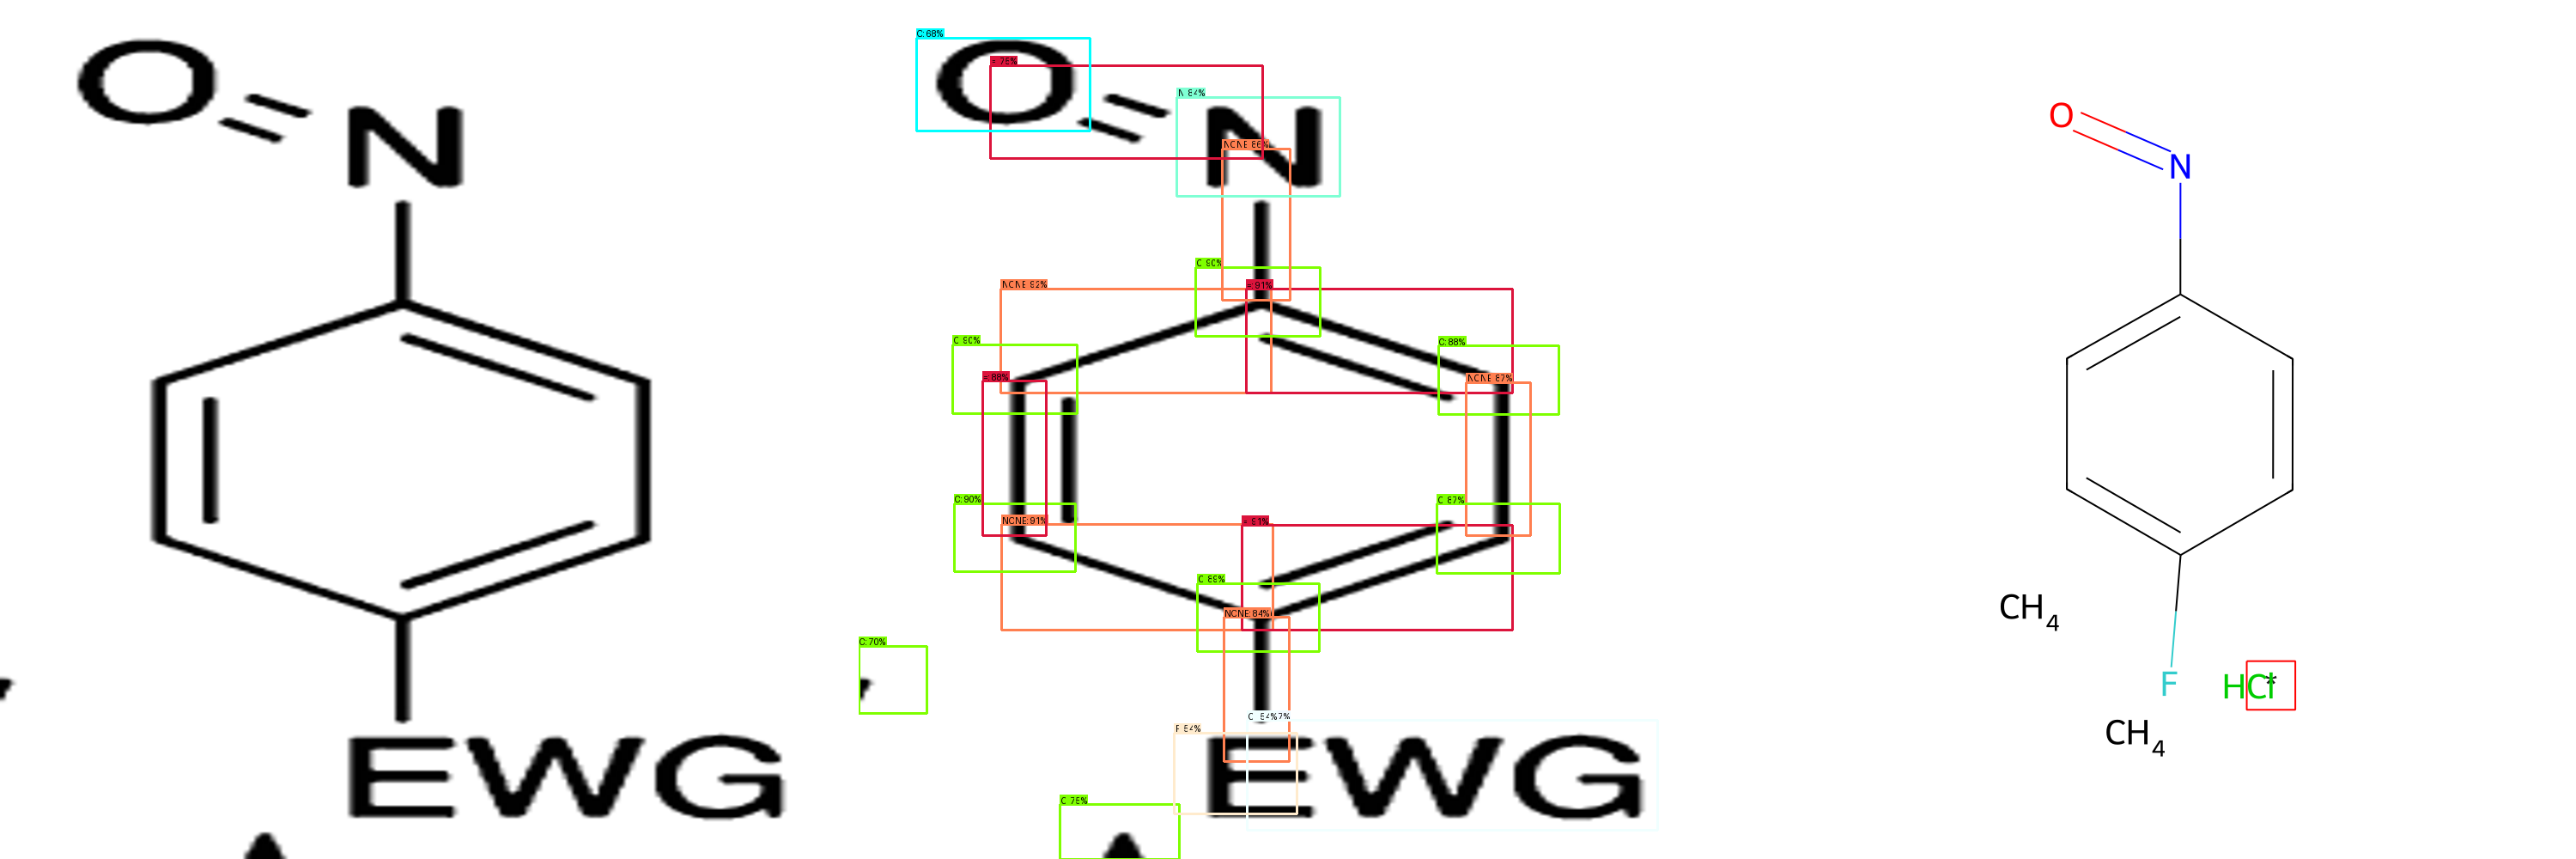

In [42]:
visual_check=True
other2pps=True
# TODO #[3H] 2H prpared box for training are too smalled, need adjust
if visual_check:
    img_ori = Image.open(image_path).convert('RGB')
    img_ori_1k = img_ori.resize((1000,1000))
    if other2pps:
        img_rebuit = Draw.MolToImage(final_mol, options=opts,size=(1000, 1000))
    else:
        img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
    combined_img = Image.new('RGB', (img_ori_1k.width + boxed_img.width + img_rebuit.width, img_ori_1k.height))
    combined_img.paste(img_ori_1k, (0, 0))
    combined_img.paste(boxed_img, (img_ori_1k.width, 0))
    combined_img.paste(img_rebuit, (img_ori_1k.width + boxed_img.width, 0))
combined_img

In [43]:
#save as onnx
import torch.onnx
import onnx
import onnxruntime as ort
# 设置为评估模式
_model.eval()
# 定义输出ONNX文件的路径
onnx_model_path = "i2mDETR_model_v2.onnx"
torch.onnx.export(
    model=_model,                     # 要转换的模型
    args=tensor,                 # 模型的输入（示例输入）
    f=onnx_model_path,                # 输出文件的路径
    export_params=True,               # 是否导出训练好的参数
    opset_version=16,                  # 使用更高的 opset 版本dummy_grid
    do_constant_folding=True,         # 是否执行常量折叠优化
    input_names=['input'],            # 输入名称（可选）
    output_names=['output'],          # 输出名称（可选）
    dynamic_axes={
        'input': {0: 'batch_size'},    # 支持动态批量大小
        'output': {0: 'batch_size'}
    }
)


# 加载并检查ONNX模型
onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX模型检查通过")

# 使用ONNX Runtime进行推理
ort_session = ort.InferenceSession(onnx_model_path)

# 准备输入数据
def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

ort_inputs = {
    ort_session.get_inputs()[0].name: to_numpy(tensor),
    # ort_session.get_inputs()[1].name: to_numpy(dummy_grid)
}
ort_outputs = ort_session.run(None, ort_inputs)

# 获取PyTorch输出
with torch.no_grad():
    torch_output = _model(tensor)

# 打印并比较结果
print("PyTorch输出:", torch_output)
print("ONNX Runtime输出:", ort_outputs[0])

# 计算两者的差异
# difference = np.abs(to_numpy(torch_output) - ort_outputs[0]).max()
# print(f"输出差异最大值: {difference}")


============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX模型检查通过
PyTorch输出: {'pred_logits': tensor([[[-5.5288, -4.5578, -4.5115,  ..., -5.4560, -5.3202, -5.9717],
         [-5.5009, -4.6031, -4.4814,  ..., -4.8978, -5.1217, -5.7569],
         [-5.1530, -4.5877, -4.1356,  ..., -4.6417, -4.5300, -5.8577],
         ...,
         [-4.1337, -2.4281, -3.1227,  ..., -4.7081, -4.7062, -6.0905],
         [-4.9607, -3.2102, -3.7347,  ..., -5.0859, -5.0976, -6.7588],
         [-4.7754, -2.8874, -3.3816,  ..., -5.0368, -5.2054, -6.4089]]]), 'pred_boxes': tensor([[[0.3244, 0.6725, 0.3166, 0.1231],
         [0.3232, 0.3972, 0.3145, 0.1214],
         [0.6044, 0.6727, 0.3150, 0.1215],
         ...,
         [0.5011, 0.5403, 0.9924, 0.5989],
         [0.0257, 0.0648, 0.0673, 0.1169],
         [0.4885, 0.2459, 0.9775, 0.3859]]])}
ONNX Runtime输出: [[[-5.528808

In [44]:
torch_output

{'pred_logits': tensor([[[-5.5288, -4.5578, -4.5115,  ..., -5.4560, -5.3202, -5.9717],
          [-5.5009, -4.6031, -4.4814,  ..., -4.8978, -5.1217, -5.7569],
          [-5.1530, -4.5877, -4.1356,  ..., -4.6417, -4.5300, -5.8577],
          ...,
          [-4.1337, -2.4281, -3.1227,  ..., -4.7081, -4.7062, -6.0905],
          [-4.9607, -3.2102, -3.7347,  ..., -5.0859, -5.0976, -6.7588],
          [-4.7754, -2.8874, -3.3816,  ..., -5.0368, -5.2054, -6.4089]]]),
 'pred_boxes': tensor([[[0.3244, 0.6725, 0.3166, 0.1231],
          [0.3232, 0.3972, 0.3145, 0.1214],
          [0.6044, 0.6727, 0.3150, 0.1215],
          ...,
          [0.5011, 0.5403, 0.9924, 0.5989],
          [0.0257, 0.0648, 0.0673, 0.1169],
          [0.4885, 0.2459, 0.9775, 0.3859]]])}

In [45]:
outputs={'pred_logits':torch.from_numpy(ort_outputs[0]),
'pred_boxes':torch.from_numpy(ort_outputs[1])
}

In [46]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
result_ = postprocessor(outputs, ori_size)
# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
selected_indices =score_ > 0.5
output={
    'labels': label_[selected_indices],
    'boxes': boxe_[selected_indices],
    'scores': score_[selected_indices]
}

filtered_output_dict={image_path: output
}


x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

In [47]:
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']
img_ori = Image.open(image_path).convert('RGB')
w_ori, h_ori = img_ori.size  # 获取原始图像的尺寸
# 计算缩放比例
scale_x = 1000 / w_ori
scale_y = 1000 / h_ori
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))
newbox = predict_boxes * [scale_x, scale_y, scale_x, scale_y]
boxed_img = draw_objs(img,
                        newbox,
                        predict_classes,
                        predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit



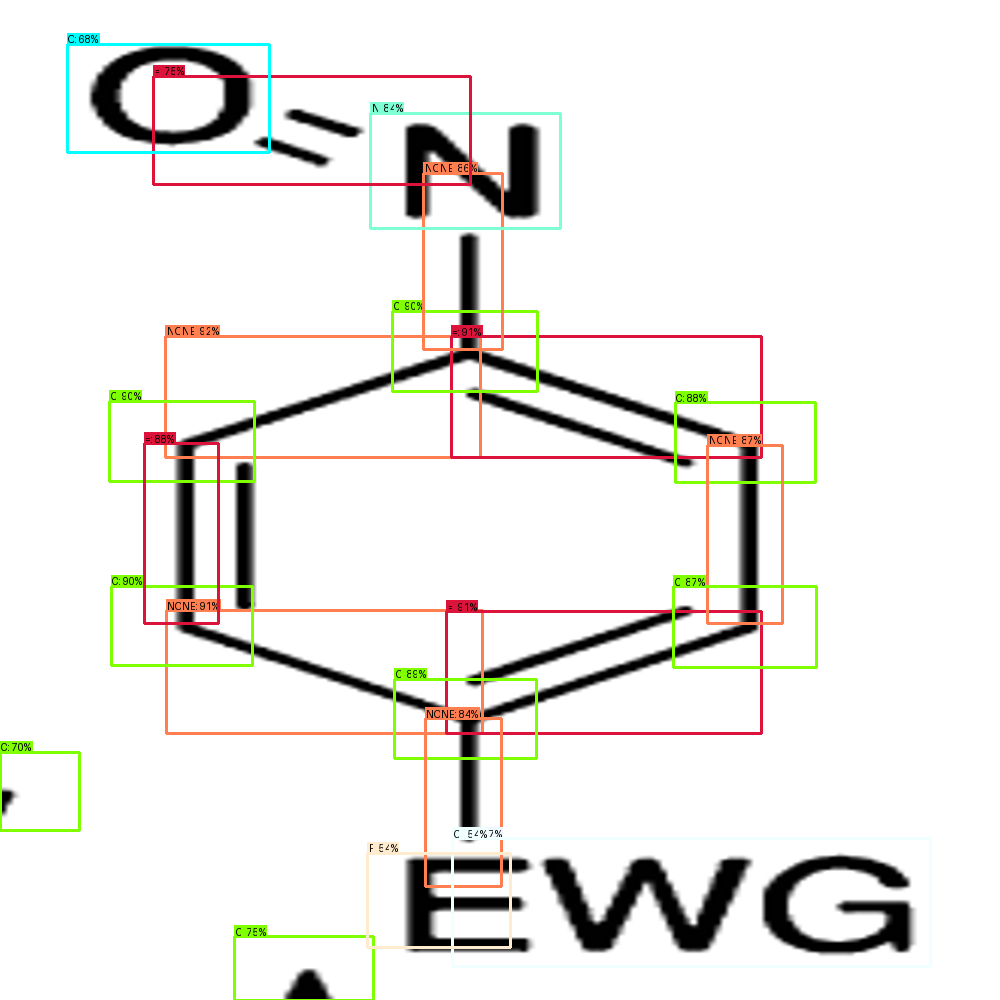

In [48]:
boxed_img

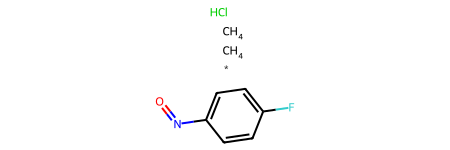

In [49]:
Chem.MolFromSmiles(smiles)

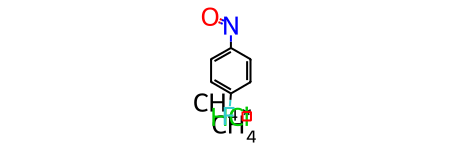

In [50]:
mol_rebuit


In [51]:
SMI_IDX=Chem.MolToSmiles(final_mol)

In [52]:
from SmilesPE.pretokenizer import atomwise_tokenizer
SMI_IDX=Chem.MolToSmiles(final_mol)
ai_smi=atomwise_tokenizer(SMI_IDX)

In [53]:
print(ai_smi)

['*', '.', 'C', '.', 'C', '.', 'Cl', '.', 'O', '=', 'N', 'c', '1', 'c', 'c', 'c', '(', 'F', ')', 'c', 'c', '1']


In [54]:
Chem.MolToSmiles(mol, canonical=False, doRandom=False, isomericSmiles=True, 
            kekuleSmiles=True)



'C1=C(N=O)C=CC(F)=C1.C.C.*.Cl'

In [55]:
Chem.MolToSmiles(mol)

'*.C.C.Cl.O=Nc1ccc(F)cc1'

In [56]:
#TODO rotable boxing  and aromatic bonding rings??

In [57]:
['US20070249620A1_p0006_x1375_y2591_c00009.png', 'US20050182067A1_p0032_x1638_y1021_c00113.png', 'US20050113580A1_p0038_x1307_y1020_c00053.png', 'US20030130506A1_p0008_x1381_y1349_c00031.png', 'US20050054819A1_p0033_x1376_y0730_c00118.png', 'US20060281700A1_p0083_x0404_y0649_c00163.png', 'US20050182067A1_p0036_x1607_y2740_c00137.png', 'US20070270434A1_p0018_x1376_y0766_c00041.png']

['US20070249620A1_p0006_x1375_y2591_c00009.png',
 'US20050182067A1_p0032_x1638_y1021_c00113.png',
 'US20050113580A1_p0038_x1307_y1020_c00053.png',
 'US20030130506A1_p0008_x1381_y1349_c00031.png',
 'US20050054819A1_p0033_x1376_y0730_c00118.png',
 'US20060281700A1_p0083_x0404_y0649_c00163.png',
 'US20050182067A1_p0036_x1607_y2740_c00137.png',
 'US20070270434A1_p0018_x1376_y0766_c00041.png']

In [58]:
# original_smiles::: CC1=C[U]=C(N2CCN(C)CC2)C=C1
# test_smiles::: Cc1c*c(N2CCN(C)CC2)cc1
# file_name:: US20070249620A1_p0006_x1375_y2591_c00009.png
# original_smiles::: COC1=C([N+](=O)[O-])C(N)=CC=C1
# test_smiles::: COc1cccc(N)c1NO.O
# file_name:: US20050182067A1_p0032_x1638_y1021_c00113.png
# original_smiles::: COC(=O)CC1=CC=CC(OCCCN(CC2=CC=CC(C(F)(F)F)=C2Cl)C[C@H](OC(=O)C2=CC=CC=C2)C2=CC=CC=C2)=C1
# test_smiles::: C.COC(=O)Cc1cccc(OCCCN(Cc2cccc(C(F)(F)F)c2Cl)C[C@@H]2OC(=O)c3cc2cccc(C)ccc3)c1
# file_name:: US20050113580A1_p0038_x1307_y1020_c00053.png
# original_smiles::: [*]C1([*])*[W]CN(S(=O)(=O)C2=CC=C(O[Ar])C=C2)C1C(=O)NO
# test_smiles::: *Oc1ccc([S](=O)(=O)N2C**C(*)(*)C2C(=O)NO)cc1
# file_name:: US20030130506A1_p0008_x1381_y1349_c00031.png
# original_smiles::: [C-]#[N+]CC1=CN=CC=C1
# test_smiles::: C.NCc1cccnc1
# file_name:: US20050054819A1_p0033_x1376_y0730_c00118.png
# original_smiles::: O=[N+]([O-])C1=CN=C(OC2CCC2)C=C1
# test_smiles::: O.ONc1ccc(OC2CCC2)nc1
# file_name:: US20060281700A1_p0083_x0404_y0649_c00163.png
# original_smiles::: O=C1COC2=CC=CC([N+](=O)[O-])=C2N1
# test_smiles::: O.O=Nc1cccc2c1NC(=O)CO2
# file_name:: US20050182067A1_p0036_x1607_y2740_c00137.png
# original_smiles::: [C-]#[N+]CC1=CC=C(OC(F)(F)F)C=C1
# test_smiles::: C#N.Cc1ccc(OC(F)(F)F)cc1
# file_name:: US20070270434A1_p0018_x1376_y0766_c00041.png
#

#TODO check the above wrongs and try fix

In [59]:
res_smiles=[]
for i,(key,value) in enumerate(filtered_output_dict.items()):
    result = []
    res_smiles.append(output_to_smiles(value,idx_to_labels,bond_labels,result)) 

In [60]:
#prediction postprocesss 
logits, boxes = outputs['pred_logits'], outputs['pred_boxes']
scores =  torch.nn.functional.sigmoid(logits)
bbox_pred = torchvision.ops.box_convert(boxes, in_fmt='cxcywh', out_fmt='xyxy')
labels_scores = torch.nn.functional.softmax(logits,dim=-1)
labels_pred = torch.argmax(labels_scores,dim=-1)

In [61]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)